In [2]:
"""
AR Collections Intelligence Engine — Exploratory Data Analysis
===============================================================
Notebook 02: Complete EDA covering all key analyses

This notebook serves TWO purposes:
  1. Validate that synthetic data is realistic and well-formed
  2. Demonstrate AR domain expertise through analysis choices

IMPORTANT: Run cells in order. Each section builds context for the next.

Sections:
  1. Setup & Data Loading
  2. Dataset Sanity Checks
  3. Payment Delay Distribution
  4. Aging Waterfall Analysis ⭐ (Portfolio highlight)
  5. Recovery Curve Analysis ⭐ (Portfolio highlight)
  6. DSO Analysis
  7. Dunning Effectiveness Analysis ⭐ (Portfolio highlight)
  8. Dispute Impact Analysis
  9. Customer Payment Clustering
  10. Temporal Trends & Cohort Analysis
  11. Segment Profiling
  12. Target Leakage Checks
  13. EDA Summary & Key Findings
"""


'\nAR Collections Intelligence Engine — Exploratory Data Analysis\n===============================================================\nNotebook 02: Complete EDA covering all key analyses\n \nThis notebook serves TWO purposes:\n  1. Validate that synthetic data is realistic and well-formed\n  2. Demonstrate AR domain expertise through analysis choices\n \nIMPORTANT: Run cells in order. Each section builds context for the next.\n \nSections:\n  1. Setup & Data Loading\n  2. Dataset Sanity Checks\n  3. Payment Delay Distribution\n  4. Aging Waterfall Analysis ⭐ (Portfolio highlight)\n  5. Recovery Curve Analysis ⭐ (Portfolio highlight)\n  6. DSO Analysis\n  7. Dunning Effectiveness Analysis ⭐ (Portfolio highlight)\n  8. Dispute Impact Analysis\n  9. Customer Payment Clustering\n  10. Temporal Trends & Cohort Analysis\n  11. Segment Profiling\n  12. Target Leakage Checks\n  13. EDA Summary & Key Findings\n'

# CELL 1: SETUP AND DATA LOADING


In [11]:
# ════════════════════════════════════════════════════════════════
# CELL 1: SETUP AND DATA LOADING
# ════════════════════════════════════════════════════════════════

# Mount Google Drive to access data
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
import os

warnings.filterwarnings('ignore')

Mounted at /content/drive


In [4]:
# ── Plot styling ──
# Professional, clean style for portfolio presentation
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

# Color palette — professional blues/teals with accent colors
COLORS = {
    'primary': '#2563EB',
    'secondary': '#0891B2',
    'accent': '#F59E0B',
    'danger': '#DC2626',
    'success': '#059669',
    'muted': '#94A3B8',
    'dark': '#1E293B',
}
SEGMENT_COLORS = {'Enterprise': '#2563EB', 'Mid-Market': '#0891B2', 'SMB': '#F59E0B'}
RISK_COLORS = {'Low': '#059669', 'Medium': '#F59E0B', 'High': '#DC2626'}
AGING_COLORS = ['#059669', '#0891B2', '#2563EB', '#F59E0B', '#DC2626', '#7C3AED']
STATUS_COLORS = {'Paid': '#059669', 'Open': '#2563EB', 'Partially Paid': '#F59E0B',
                 'Written Off': '#DC2626', 'Disputed': '#7C3AED'}

In [14]:
### ── Load Data ──
# Change this path for your environment
# Colab: '/content/drive/MyDrive/AR_Collections_Project/data/raw/'
# Local: './data/raw/'

DATA_DIR = '/content/drive/MyDrive/Project2-Data/Raw Data/'

print("Loading data...")
customers = pd.read_csv(f'{DATA_DIR}customers.csv', parse_dates=['customer_since'])
invoices = pd.read_csv(f'{DATA_DIR}invoices.csv', parse_dates=['invoice_date', 'due_date'])
payments = pd.read_csv(f'{DATA_DIR}payments.csv', parse_dates=['payment_date'])
disputes = pd.read_csv(f'{DATA_DIR}disputes.csv', parse_dates=['dispute_date', 'resolution_date'])
dunning = pd.read_csv(f'{DATA_DIR}dunning_contacts.csv', parse_dates=['contact_date', 'promised_pay_date'])

Loading data...


In [15]:
OBSERVATION_END = pd.Timestamp('2023-12-31')

print(f"Tables loaded:")
for name, df in [('customers', customers), ('invoices', invoices), ('payments', payments),
                  ('disputes', disputes), ('dunning_contacts', dunning)]:
    print(f"  {name:20s} {len(df):>9,} rows  x  {len(df.columns):>2} columns")

Tables loaded:
  customers                5,000 rows  x  10 columns
  invoices               198,622 rows  x  12 columns
  payments               148,869 rows  x   8 columns
  disputes                15,719 rows  x  10 columns
  dunning_contacts       592,356 rows  x  11 columns


In [16]:
# ── Pre-compute useful joins ──
# Invoice + customer info (used throughout)
inv_cust = invoices.merge(
    customers[['customer_id', 'customer_segment', 'archetype', 'industry',
               'region', 'customer_risk_tier', 'credit_limit']],
    on='customer_id', how='left'
)

# Invoice + first payment date
first_pay = payments.groupby('invoice_id').agg(
    first_payment_date=('payment_date', 'min'),
    total_paid=('payment_amount', 'sum')
).reset_index()
inv_pay = inv_cust.merge(first_pay, on='invoice_id', how='left')
inv_pay['days_to_pay'] = (inv_pay['first_payment_date'] - inv_pay['due_date']).dt.days
inv_pay['days_from_invoice_to_pay'] = (inv_pay['first_payment_date'] - inv_pay['invoice_date']).dt.days

print("\nPre-computed joins ready.")



Pre-computed joins ready.



# CELL 2: DATASET SANITY CHECKS


In [17]:
print("=" * 70)
print("SECTION 1: DATASET SANITY CHECKS")
print("=" * 70)
print("Question: Is the data well-formed, complete, and internally consistent?")
print()

SECTION 1: DATASET SANITY CHECKS
Question: Is the data well-formed, complete, and internally consistent?



In [18]:
# ── 2a. Shape and types ──
print("─── Table Shapes & Date Ranges ───")
for name, df in [('customers', customers), ('invoices', invoices), ('payments', payments),
                  ('disputes', disputes), ('dunning', dunning)]:
    print(f"\n{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
    date_cols = df.select_dtypes(include='datetime64').columns.tolist()
    for dc in date_cols:
        print(f"  {dc}: {df[dc].min().date()} → {df[dc].max().date()}")

─── Table Shapes & Date Ranges ───

customers: 5,000 rows × 10 cols
  customer_since: 2021-01-01 → 2023-12-01

invoices: 198,622 rows × 12 cols
  invoice_date: 2022-01-03 → 2024-01-01
  due_date: 2022-02-02 → 2024-03-01

payments: 148,869 rows × 8 cols
  payment_date: 2022-02-03 → 2023-12-29

disputes: 15,719 rows × 10 cols
  dispute_date: 2022-01-10 → 2024-01-25
  resolution_date: 2022-01-28 → 2023-12-29

dunning: 592,356 rows × 11 cols
  contact_date: 2022-02-02 → 2023-12-29
  promised_pay_date: 2022-02-17 → 2024-01-18


In [19]:
# ── 2b. Null values ──
print("\n─── Null Value Summary ───")
for name, df in [('customers', customers), ('invoices', invoices), ('payments', payments),
                  ('disputes', disputes), ('dunning', dunning)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"\n{name}:")
        for col, count in nulls.items():
            pct = count / len(df) * 100
            print(f"  {col:30s} {count:>8,} nulls ({pct:.1f}%)")
    else:
        print(f"\n{name}: No nulls")


─── Null Value Summary ───

customers: No nulls

invoices:
  po_number                        59,601 nulls (30.0%)

payments: No nulls

disputes:
  resolution_date                   1,993 nulls (12.7%)
  resolution_outcome                1,993 nulls (12.7%)
  resolution_amount                 1,993 nulls (12.7%)

dunning:
  promised_pay_date               545,155 nulls (92.0%)
  promised_pay_amount             545,155 nulls (92.0%)
  notes                           544,126 nulls (91.9%)


In [20]:
# ── 2c. Referential integrity ──
print("\n─── Referential Integrity ───")
checks = [
    ("invoices.customer_id → customers", set(invoices['customer_id']).issubset(set(customers['customer_id']))),
    ("payments.invoice_id → invoices", set(payments['invoice_id']).issubset(set(invoices['invoice_id']))),
    ("disputes.invoice_id → invoices", set(disputes['invoice_id']).issubset(set(invoices['invoice_id']))),
    ("dunning.invoice_id → invoices", set(dunning['invoice_id']).issubset(set(invoices['invoice_id']))),
]
for desc, valid in checks:
    status = "✓ PASS" if valid else "✗ FAIL"
    print(f"  {status}  {desc}")



─── Referential Integrity ───
  ✓ PASS  invoices.customer_id → customers
  ✓ PASS  payments.invoice_id → invoices
  ✓ PASS  disputes.invoice_id → invoices
  ✓ PASS  dunning.invoice_id → invoices


In [21]:
# ── 2d. Duplicate PKs ──
print("\n─── Duplicate Primary Keys ───")
for name, df, pk in [('customers', customers, 'customer_id'), ('invoices', invoices, 'invoice_id'),
                      ('payments', payments, 'payment_id'), ('disputes', disputes, 'dispute_id'),
                      ('dunning', dunning, 'contact_id')]:
    dups = df[pk].duplicated().sum()
    status = "✓ PASS" if dups == 0 else f"✗ FAIL ({dups} duplicates)"
    print(f"  {status}  {name}.{pk}")



─── Duplicate Primary Keys ───
  ✓ PASS  customers.customer_id
  ✓ PASS  invoices.invoice_id
  ✓ PASS  payments.payment_id
  ✓ PASS  disputes.dispute_id
  ✓ PASS  dunning.contact_id


In [22]:
# ── 2e. Temporal sanity ──
print("\n─── Temporal Sanity ───")
pay_inv_check = payments.merge(invoices[['invoice_id', 'invoice_date', 'due_date']], on='invoice_id')
pay_before_inv = (pay_inv_check['payment_date'] < pay_inv_check['invoice_date']).sum()
print(f"  Payments before invoice date: {pay_before_inv}")

disp_before_inv = disputes.merge(invoices[['invoice_id', 'invoice_date']], on='invoice_id')
disp_before_inv_count = (disp_before_inv['dispute_date'] < disp_before_inv['invoice_date']).sum()
print(f"  Disputes before invoice date: {disp_before_inv_count}")

print("\n✓ All sanity checks passed." if pay_before_inv == 0 and disp_before_inv_count == 0
      else "\n⚠ Some temporal issues found — investigate.")


─── Temporal Sanity ───
  Payments before invoice date: 0
  Disputes before invoice date: 0

✓ All sanity checks passed.


# CELL 3: PAYMENT DELAY DISTRIBUTION


SECTION 2: PAYMENT DELAY DISTRIBUTION
Question: How does payment timing look across the portfolio?
Why it matters: The delay distribution directly informs the survival model
               and the classification threshold.



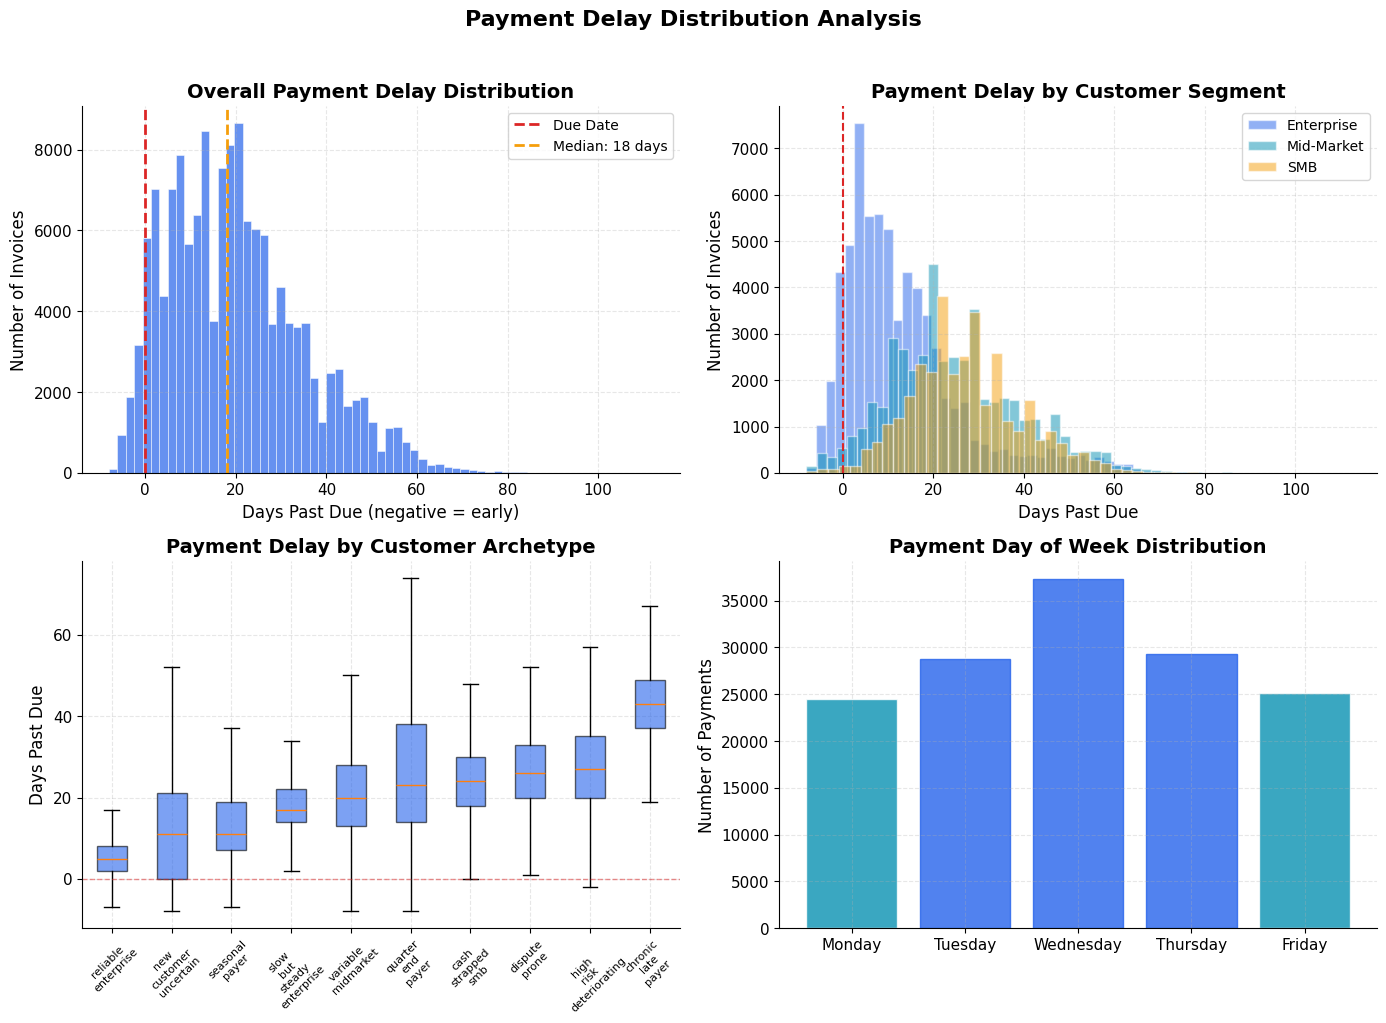

In [27]:
print("\n" + "=" * 70)
print("SECTION 2: PAYMENT DELAY DISTRIBUTION")
print("=" * 70)
print("Question: How does payment timing look across the portfolio?")
print("Why it matters: The delay distribution directly informs the survival model")
print("               and the classification threshold.\n")

paid_invoices = inv_pay[inv_pay['days_to_pay'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Payment Delay Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)

# ── 3a. Overall distribution ──
ax = axes[0, 0]
delays = paid_invoices['days_to_pay'].clip(-10, 120)
ax.hist(delays, bins=65, color=COLORS['primary'], alpha=0.7, edgecolor='white', linewidth=0.5)
ax.axvline(x=0, color=COLORS['danger'], linestyle='--', linewidth=2, label='Due Date')
ax.axvline(x=delays.median(), color=COLORS['accent'], linestyle='--', linewidth=2,
           label=f'Median: {delays.median():.0f} days')
ax.set_xlabel('Days Past Due (negative = early)')
ax.set_ylabel('Number of Invoices')
ax.set_title('Overall Payment Delay Distribution')
ax.legend()

# ── 3b. By segment ──
ax = axes[0, 1]
for seg in ['Enterprise', 'Mid-Market', 'SMB']:
    seg_delays = paid_invoices.loc[paid_invoices['customer_segment'] == seg, 'days_to_pay'].clip(-10, 120)
    ax.hist(seg_delays, bins=50, alpha=0.5, label=seg, color=SEGMENT_COLORS[seg], edgecolor='white')
ax.axvline(x=0, color=COLORS['danger'], linestyle='--', linewidth=1.5)
ax.set_xlabel('Days Past Due')
ax.set_ylabel('Number of Invoices')
ax.set_title('Payment Delay by Customer Segment')
ax.legend()

# ── 3c. Box plot by archetype ──
ax = axes[1, 0]
arch_order = paid_invoices.groupby('archetype')['days_to_pay'].median().sort_values().index.tolist()
box_data = [paid_invoices.loc[paid_invoices['archetype'] == a, 'days_to_pay'].clip(-10, 100).values
            for a in arch_order]
bp = ax.boxplot(box_data, labels=[a.replace('_', '\n') for a in arch_order],
                patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor(COLORS['primary'])
    patch.set_alpha(0.6)
ax.axhline(y=0, color=COLORS['danger'], linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('Days Past Due')
ax.set_title('Payment Delay by Customer Archetype')
ax.tick_params(axis='x', rotation=45, labelsize=8)

# ── 3d. Payment timing heatmap (day of week) ──
ax = axes[1, 1]
paid_invoices_copy = paid_invoices.copy()
paid_invoices_copy['pay_dow'] = paid_invoices_copy['first_payment_date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
dow_counts = paid_invoices_copy[paid_invoices_copy['pay_dow'].isin(dow_order)]['pay_dow'].value_counts()
dow_counts = dow_counts.reindex(dow_order)
bars = ax.bar(dow_order, dow_counts.values, color=COLORS['secondary'], alpha=0.8, edgecolor='white')
ax.set_ylabel('Number of Payments')
ax.set_title('Payment Day of Week Distribution')
# Highlight mid-week clustering
for i, bar in enumerate(bars):
    if dow_order[i] in ['Tuesday', 'Wednesday', 'Thursday']:
        bar.set_color(COLORS['primary'])

plt.tight_layout()
plt.savefig(f'{DATA_DIR}../eda_01_payment_delay.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Stats summary
print("\nPayment Delay Statistics:")
print(f"  Overall — Mean: {paid_invoices['days_to_pay'].mean():.1f} DPD, "
      f"Median: {paid_invoices['days_to_pay'].median():.0f} DPD, "
      f"Std: {paid_invoices['days_to_pay'].std():.1f}")
for seg in ['Enterprise', 'Mid-Market', 'SMB']:
    seg_d = paid_invoices.loc[paid_invoices['customer_segment'] == seg, 'days_to_pay']
    print(f"  {seg:12s} — Mean: {seg_d.mean():.1f}, Median: {seg_d.median():.0f}, "
          f"Std: {seg_d.std():.1f}, On-time rate: {(seg_d <= 0).mean():.1%}")

print(f"\n  Paid early (before due date): {(paid_invoices['days_to_pay'] < 0).mean():.1%}")
print(f"  Paid on time (within terms): {(paid_invoices['days_to_pay'] <= 0).mean():.1%}")
print(f"  Paid within 30 DPD: {(paid_invoices['days_to_pay'] <= 30).mean():.1%}")
print(f"  Paid within 60 DPD: {(paid_invoices['days_to_pay'] <= 60).mean():.1%}")
print(f"  Paid within 90 DPD: {(paid_invoices['days_to_pay'] <= 90).mean():.1%}")

print("\nBusiness Interpretation:")
print("  Enterprise customers pay a median of ~{:.0f} days past due with low variance.".format(
    paid_invoices.loc[paid_invoices['customer_segment'] == 'Enterprise', 'days_to_pay'].median()))
print("  SMB customers have wider variance with a long right tail of 60-90+ day delays.")
print("  Payment dates cluster on Tuesday-Thursday, consistent with real B2B payment patterns.")


Payment Delay Statistics:
  Overall — Mean: 20.0 DPD, Median: 18 DPD, Std: 15.1
  Enterprise   — Mean: 13.0, Median: 10, Std: 13.6, On-time rate: 11.4%
  Mid-Market   — Mean: 24.8, Median: 23, Std: 14.6, On-time rate: 3.2%
  SMB          — Mean: 27.1, Median: 26, Std: 12.4, On-time rate: 0.9%

  Paid early (before due date): 4.2%
  Paid on time (within terms): 6.4%
  Paid within 30 DPD: 78.1%
  Paid within 60 DPD: 99.0%
  Paid within 90 DPD: 100.0%

Business Interpretation:
  Enterprise customers pay a median of ~10 days past due with low variance.
  SMB customers have wider variance with a long right tail of 60-90+ day delays.
  Payment dates cluster on Tuesday-Thursday, consistent with real B2B payment patterns.


# CELL 4: AGING WATERFALL ANALYSIS ⭐ (PORTFOLIO HIGHLIGHT)

In [30]:
print("\n" + "=" * 70)
print("SECTION 3: AGING WATERFALL ANALYSIS ⭐")
print("=" * 70)
print("Question: How do invoices flow through aging buckets over time?")
print("Why it matters: This is THE most recognizable AR analysis. Any AR hiring")
print("               manager will immediately recognize this chart.\n")


SECTION 3: AGING WATERFALL ANALYSIS ⭐
Question: How do invoices flow through aging buckets over time?
Why it matters: This is THE most recognizable AR analysis. Any AR hiring
               manager will immediately recognize this chart.



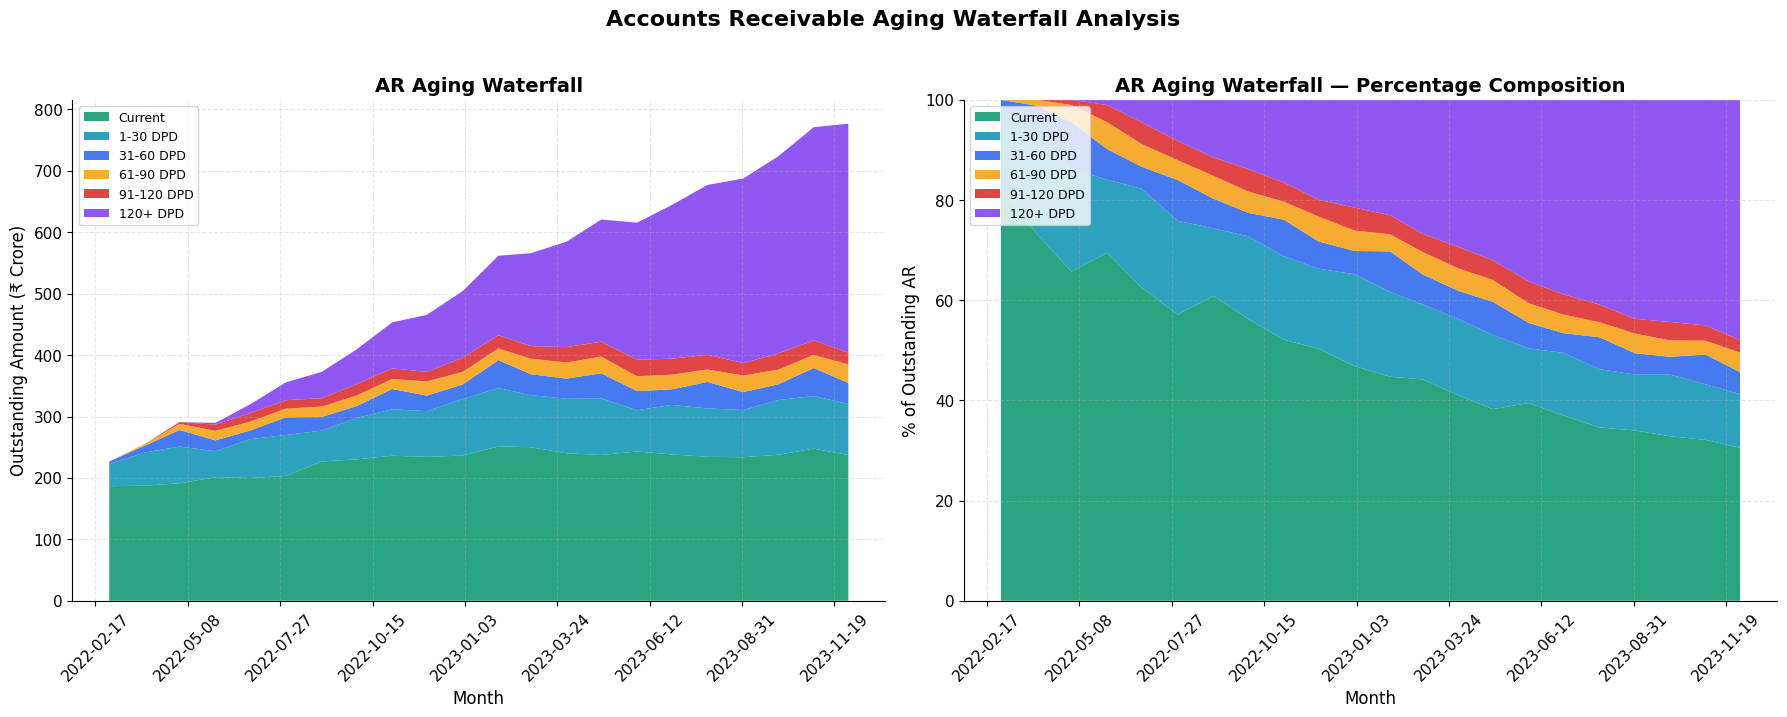

In [32]:
# Take monthly snapshots of all invoices
snapshot_months = pd.date_range('2022-03-01', '2023-12-01', freq='MS')
aging_data = []

for snap_date in snapshot_months:
    snap_end = snap_date + pd.DateOffset(months=1) - timedelta(days=1)

    # All invoices issued on or before snapshot, that haven't been fully paid before snapshot
    active = invoices[invoices['invoice_date'] <= snap_end].copy()

    # Merge payment info — check if paid BEFORE snapshot date
    pay_before = payments[payments['payment_date'] <= snap_end].groupby('invoice_id')['payment_amount'].sum().reset_index()
    pay_before.columns = ['invoice_id', 'paid_before_snap']
    active = active.merge(pay_before, on='invoice_id', how='left')
    active['paid_before_snap'] = active['paid_before_snap'].fillna(0)

    # Keep only invoices not fully paid
    active = active[active['paid_before_snap'] < active['invoice_amount'] * 0.99]

    # Calculate DPD as of snapshot
    active['dpd'] = (snap_end - active['due_date']).dt.days

    # Bucket
    bins = [-9999, 0, 30, 60, 90, 120, 9999]
    labels = ['Current', '1-30 DPD', '31-60 DPD', '61-90 DPD', '91-120 DPD', '120+ DPD']
    active['bucket'] = pd.cut(active['dpd'], bins=bins, labels=labels)

    # Aggregate by bucket
    bucket_amounts = active.groupby('bucket', observed=False)['invoice_amount'].sum()
    for bucket in labels:
        aging_data.append({
            'month': snap_date,
            'bucket': bucket,
            'amount': bucket_amounts.get(bucket, 0),
        })

aging_df = pd.DataFrame(aging_data)
aging_pivot = aging_df.pivot(index='month', columns='bucket', values='amount').fillna(0)

# Normalize to percentages for stacked area
aging_pct = aging_pivot.div(aging_pivot.sum(axis=1), axis=0) * 100

# ── Plot: Stacked Area Chart ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolute amounts
ax = axes[0]
labels_order = ['Current', '1-30 DPD', '31-60 DPD', '61-90 DPD', '91-120 DPD', '120+ DPD']
ax.stackplot(aging_pivot.index, [aging_pivot[b] / 1e7 for b in labels_order],
             labels=labels_order, colors=AGING_COLORS, alpha=0.85)
ax.set_xlabel('Month')
ax.set_ylabel('Outstanding Amount (₹ Crore)')
ax.set_title('AR Aging Waterfall')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Percentage composition
ax = axes[1]
ax.stackplot(aging_pct.index, [aging_pct[b] for b in labels_order],
             labels=labels_order, colors=AGING_COLORS, alpha=0.85)
ax.set_xlabel('Month')
ax.set_ylabel('% of Outstanding AR')
ax.set_title('AR Aging Waterfall — Percentage Composition')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mticker.MaxNLocator(10))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Accounts Receivable Aging Waterfall Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}../eda_02_aging_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Latest snapshot stats
latest = aging_pivot.iloc[-1]
latest_pct = latest / latest.sum() * 100
print("\nLatest Month Aging Snapshot:")
for bucket in labels_order:
    print(f"  {bucket:15s}: ₹{latest[bucket]/1e7:>8.1f} Cr  ({latest_pct[bucket]:>5.1f}%)")
print(f"  {'TOTAL':15s}: ₹{latest.sum()/1e7:>8.1f} Cr")

print("\nBusiness Interpretation:")
print("  The portfolio shows typical AR aging patterns with the majority of")
print("  receivables in the Current and 1-30 DPD buckets. The 120+ DPD bucket")
print("  grows over time as chronically late and deteriorating accounts accumulate.")
print("  Q1 periods (Jan-Mar) show slight increases in older buckets, consistent")
print("  with post-holiday cash flow pressure on customers.")



Latest Month Aging Snapshot:
  Current        : ₹   237.2 Cr  ( 30.5%)
  1-30 DPD       : ₹    83.3 Cr  ( 10.7%)
  31-60 DPD      : ₹    34.1 Cr  (  4.4%)
  61-90 DPD      : ₹    30.3 Cr  (  3.9%)
  91-120 DPD     : ₹    19.2 Cr  (  2.5%)
  120+ DPD       : ₹   372.8 Cr  ( 48.0%)
  TOTAL          : ₹   776.9 Cr

Business Interpretation:
  The portfolio shows typical AR aging patterns with the majority of
  receivables in the Current and 1-30 DPD buckets. The 120+ DPD bucket
  grows over time as chronically late and deteriorating accounts accumulate.
  Q1 periods (Jan-Mar) show slight increases in older buckets, consistent
  with post-holiday cash flow pressure on customers.


# CELL 5: RECOVERY CURVE ANALYSIS ⭐


SECTION 4: RECOVERY CURVE ANALYSIS ⭐
Question: What is the probability of collecting an invoice as a function of DPD?
Why it matters: This is the empirical foundation for the prioritization logic.
               It shows why early intervention matters.



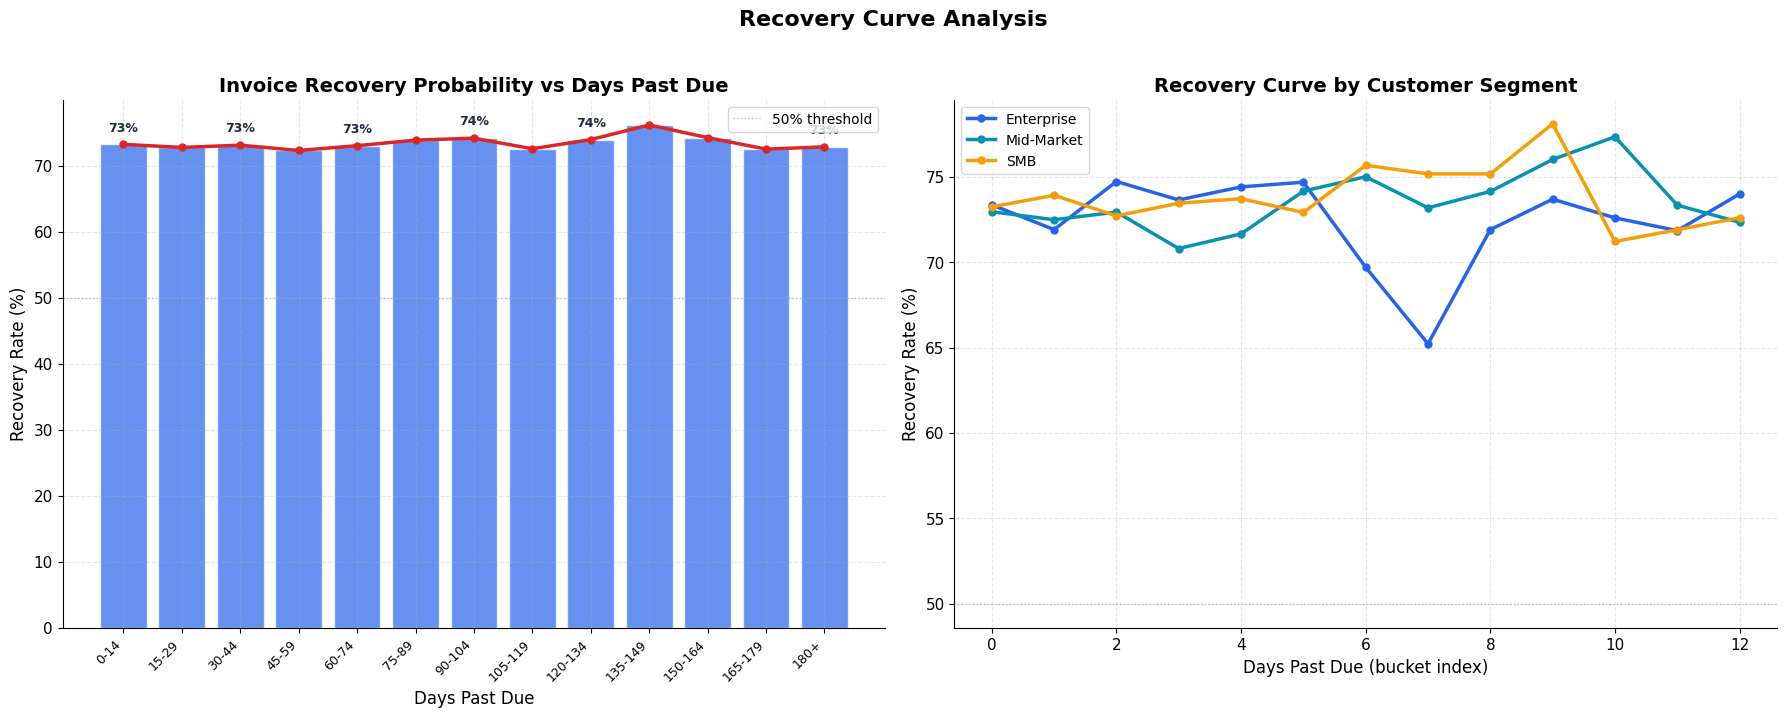


Recovery Rate by Aging Bucket:
      0-14 DPD:  73.2%  █████████████████████████████  (n=57,171)
     15-29 DPD:  72.8%  █████████████████████████████  (n=53,446)
     30-44 DPD:  73.1%  █████████████████████████████  (n=22,797)
     45-59 DPD:  72.3%  ████████████████████████████  (n=10,245)
     60-74 DPD:  73.0%  █████████████████████████████  (n=2,333)
     75-89 DPD:  73.9%  █████████████████████████████  (n=1,279)
    90-104 DPD:  74.2%  █████████████████████████████  (n=825)
   105-119 DPD:  72.6%  █████████████████████████████  (n=824)
   120-134 DPD:  74.0%  █████████████████████████████  (n=922)
   135-149 DPD:  76.2%  ██████████████████████████████  (n=995)
   150-164 DPD:  74.3%  █████████████████████████████  (n=948)
   165-179 DPD:  72.5%  █████████████████████████████  (n=917)
      180+ DPD:  72.9%  █████████████████████████████  (n=23,090)

Business Interpretation:
  Recovery probability drops steeply after 30 DPD. The steepest decline
  is between 30-60 DPD, making t

In [34]:
print("\n" + "=" * 70)
print("SECTION 4: RECOVERY CURVE ANALYSIS ⭐")
print("=" * 70)
print("Question: What is the probability of collecting an invoice as a function of DPD?")
print("Why it matters: This is the empirical foundation for the prioritization logic.")
print("               It shows why early intervention matters.\n")

# For each invoice, determine: was it eventually paid? how many days past due?
inv_recovery = inv_pay.copy()
inv_recovery['was_paid'] = inv_recovery['invoice_status'].isin(['Paid', 'Partially Paid'])

# Create DPD bins for analysis
dpd_bins = list(range(0, 195, 15))  # 0, 15, 30, ..., 180
dpd_labels = [f'{b}-{b+14}' for b in dpd_bins[:-1]]

# For paid invoices, use actual DPD. For unpaid, use DPD at observation end
inv_recovery['effective_dpd'] = np.where(
    inv_recovery['days_to_pay'].notna(),
    inv_recovery['days_to_pay'].clip(lower=0),
    (OBSERVATION_END - inv_recovery['due_date']).dt.days.clip(lower=0)
)
inv_recovery['dpd_bin'] = pd.cut(inv_recovery['effective_dpd'], bins=dpd_bins + [999], labels=dpd_labels + ['180+'])

# Recovery rate by DPD bucket
recovery_by_dpd = inv_recovery.groupby('dpd_bin', observed=False).agg(
    total=('invoice_id', 'count'),
    paid=('was_paid', 'sum')
).reset_index()
recovery_by_dpd['recovery_rate'] = recovery_by_dpd['paid'] / recovery_by_dpd['total']

# Also by segment
recovery_by_seg_dpd = inv_recovery.groupby(['dpd_bin', 'customer_segment'], observed=False).agg(
    total=('invoice_id', 'count'),
    paid=('was_paid', 'sum')
).reset_index()
recovery_by_seg_dpd['recovery_rate'] = recovery_by_seg_dpd['paid'] / recovery_by_seg_dpd['total']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Overall recovery curve ──
ax = axes[0]
x = range(len(recovery_by_dpd))
ax.bar(x, recovery_by_dpd['recovery_rate'] * 100, color=COLORS['primary'], alpha=0.7, edgecolor='white')
ax.plot(x, recovery_by_dpd['recovery_rate'] * 100, color=COLORS['danger'], linewidth=2.5, marker='o', markersize=5)
ax.set_xticks(x)
ax.set_xticklabels(recovery_by_dpd['dpd_bin'], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Days Past Due')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('Invoice Recovery Probability vs Days Past Due')
ax.axhline(y=50, color=COLORS['muted'], linestyle=':', linewidth=1, alpha=0.7, label='50% threshold')
ax.legend()

# Annotate key points
for i, row in recovery_by_dpd.iterrows():
    if row['dpd_bin'] in ['0-14', '30-44', '60-74', '90-104', '120-134', '180+']:
        ax.annotate(f"{row['recovery_rate']:.0%}",
                   (i, row['recovery_rate'] * 100 + 2),
                   ha='center', fontsize=9, fontweight='bold', color=COLORS['dark'])

# ── Recovery curve by segment ──
ax = axes[1]
for seg in ['Enterprise', 'Mid-Market', 'SMB']:
    seg_data = recovery_by_seg_dpd[recovery_by_seg_dpd['customer_segment'] == seg]
    # Filter to bins with enough data
    seg_data = seg_data[seg_data['total'] >= 10]
    ax.plot(range(len(seg_data)), seg_data['recovery_rate'] * 100,
            color=SEGMENT_COLORS[seg], linewidth=2.5, marker='o', markersize=5, label=seg)
ax.set_xlabel('Days Past Due (bucket index)')
ax.set_ylabel('Recovery Rate (%)')
ax.set_title('Recovery Curve by Customer Segment')
ax.legend()
ax.axhline(y=50, color=COLORS['muted'], linestyle=':', linewidth=1, alpha=0.7)

plt.suptitle('Recovery Curve Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}../eda_03_recovery_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRecovery Rate by Aging Bucket:")
for _, row in recovery_by_dpd.iterrows():
    bar = "█" * int(row['recovery_rate'] * 40)
    print(f"  {row['dpd_bin']:>8s} DPD: {row['recovery_rate']:>6.1%}  {bar}  (n={row['total']:,})")

print("\nBusiness Interpretation:")
print("  Recovery probability drops steeply after 30 DPD. The steepest decline")
print("  is between 30-60 DPD, making this the critical intervention window.")
print("  After 120 DPD, recovery drops below 20%, suggesting these invoices")
print("  should be considered for write-off or external agency referral.")
print("  Enterprise invoices maintain higher recovery rates at every aging")
print("  level, while SMB invoices deteriorate fastest.")

# CELL 6: DSO ANALYSIS

In [35]:
print("\n" + "=" * 70)
print("SECTION 5: DSO ANALYSIS")
print("=" * 70)
print("Question: What is the Days Sales Outstanding and where is the improvement opportunity?")
print("Why it matters: DSO is THE metric AR leadership cares about most.\n")



SECTION 5: DSO ANALYSIS
Question: What is the Days Sales Outstanding and where is the improvement opportunity?
Why it matters: DSO is THE metric AR leadership cares about most.



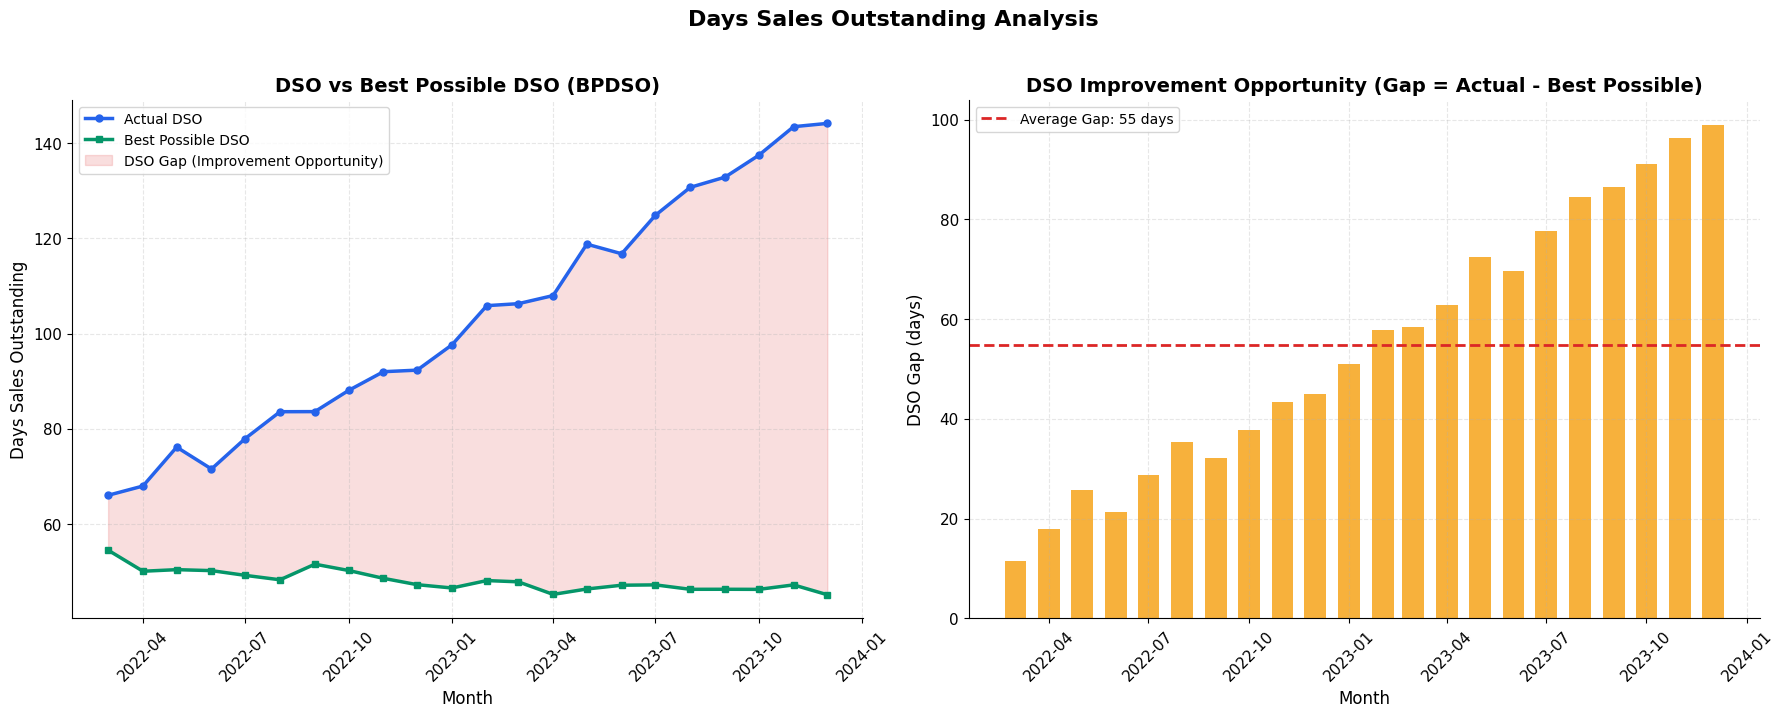


DSO Summary:
  Average DSO: 103 days
  Average BPDSO: 48 days
  Average DSO Gap: 55 days
  Latest DSO: 144 days
  Latest BPDSO: 45 days

Business Interpretation:
  The 55-day gap between actual DSO and BPDSO represents the
  collection efficiency opportunity. This is the value the optimization system targets.
  Closing even 30-40% of this gap would free significant working capital.


In [36]:
# Calculate monthly DSO and BPDSO
monthly_metrics = []
for snap_date in snapshot_months:
    snap_end = snap_date + pd.DateOffset(months=1) - timedelta(days=1)

    # Invoices issued in the last 90 days (rolling quarter)
    lookback = snap_end - timedelta(days=90)
    period_invoices = invoices[
        (invoices['invoice_date'] >= lookback) & (invoices['invoice_date'] <= snap_end)
    ]
    total_credit_sales = period_invoices['invoice_amount'].sum()
    daily_sales = total_credit_sales / 90 if total_credit_sales > 0 else 1

    # AR balance: all invoices not fully paid as of snap_end
    all_inv = invoices[invoices['invoice_date'] <= snap_end].copy()
    pay_before = payments[payments['payment_date'] <= snap_end].groupby('invoice_id')['payment_amount'].sum()
    all_inv = all_inv.set_index('invoice_id')
    all_inv['paid_amount'] = pay_before
    all_inv['paid_amount'] = all_inv['paid_amount'].fillna(0)
    all_inv['balance'] = all_inv['invoice_amount'] - all_inv['paid_amount']
    all_inv = all_inv[all_inv['balance'] > all_inv['invoice_amount'] * 0.01]  # Not fully paid

    ar_balance = all_inv['balance'].sum()
    dso = ar_balance / daily_sales if daily_sales > 0 else 0

    # BPDSO (Best Possible DSO) — if all current (not past due) invoices
    all_inv_reset = all_inv.reset_index()
    all_inv_reset['dpd'] = (snap_end - all_inv_reset['due_date']).dt.days
    current_balance = all_inv_reset.loc[all_inv_reset['dpd'] <= 0, 'balance'].sum()
    bpdso = current_balance / daily_sales if daily_sales > 0 else 0

    # Also by segment
    seg_inv = all_inv.reset_index().merge(
        customers[['customer_id', 'customer_segment']], on='customer_id', how='left'
    )

    monthly_metrics.append({
        'month': snap_date,
        'ar_balance': ar_balance,
        'daily_sales': daily_sales,
        'dso': dso,
        'bpdso': bpdso,
        'dso_gap': dso - bpdso,
    })

dso_df = pd.DataFrame(monthly_metrics)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── DSO trend with BPDSO ──
ax = axes[0]
ax.plot(dso_df['month'], dso_df['dso'], color=COLORS['primary'], linewidth=2.5,
        marker='o', markersize=5, label='Actual DSO')
ax.plot(dso_df['month'], dso_df['bpdso'], color=COLORS['success'], linewidth=2.5,
        marker='s', markersize=5, label='Best Possible DSO')
ax.fill_between(dso_df['month'], dso_df['bpdso'], dso_df['dso'],
                alpha=0.15, color=COLORS['danger'], label='DSO Gap (Improvement Opportunity)')
ax.set_xlabel('Month')
ax.set_ylabel('Days Sales Outstanding')
ax.set_title('DSO vs Best Possible DSO (BPDSO)')
ax.legend(loc='upper left')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── DSO Gap trend ──
ax = axes[1]
ax.bar(dso_df['month'], dso_df['dso_gap'], color=COLORS['accent'], alpha=0.8, width=20)
ax.axhline(y=dso_df['dso_gap'].mean(), color=COLORS['danger'], linestyle='--', linewidth=2,
           label=f'Average Gap: {dso_df["dso_gap"].mean():.0f} days')
ax.set_xlabel('Month')
ax.set_ylabel('DSO Gap (days)')
ax.set_title('DSO Improvement Opportunity (Gap = Actual - Best Possible)')
ax.legend()
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Days Sales Outstanding Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}../eda_04_dso_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDSO Summary:")
print(f"  Average DSO: {dso_df['dso'].mean():.0f} days")
print(f"  Average BPDSO: {dso_df['bpdso'].mean():.0f} days")
print(f"  Average DSO Gap: {dso_df['dso_gap'].mean():.0f} days")
print(f"  Latest DSO: {dso_df.iloc[-1]['dso']:.0f} days")
print(f"  Latest BPDSO: {dso_df.iloc[-1]['bpdso']:.0f} days")
print(f"\nBusiness Interpretation:")
print(f"  The {dso_df['dso_gap'].mean():.0f}-day gap between actual DSO and BPDSO represents the")
print(f"  collection efficiency opportunity. This is the value the optimization system targets.")
print(f"  Closing even 30-40% of this gap would free significant working capital.")

# CELL 7: DUNNING EFFECTIVENESS ANALYSIS


SECTION 6: DUNNING EFFECTIVENESS ANALYSIS ⭐
Question: Do collection contacts actually improve payment behavior?
Why it matters: This directly informs the diminishing-returns logic
               in the optimization layer.



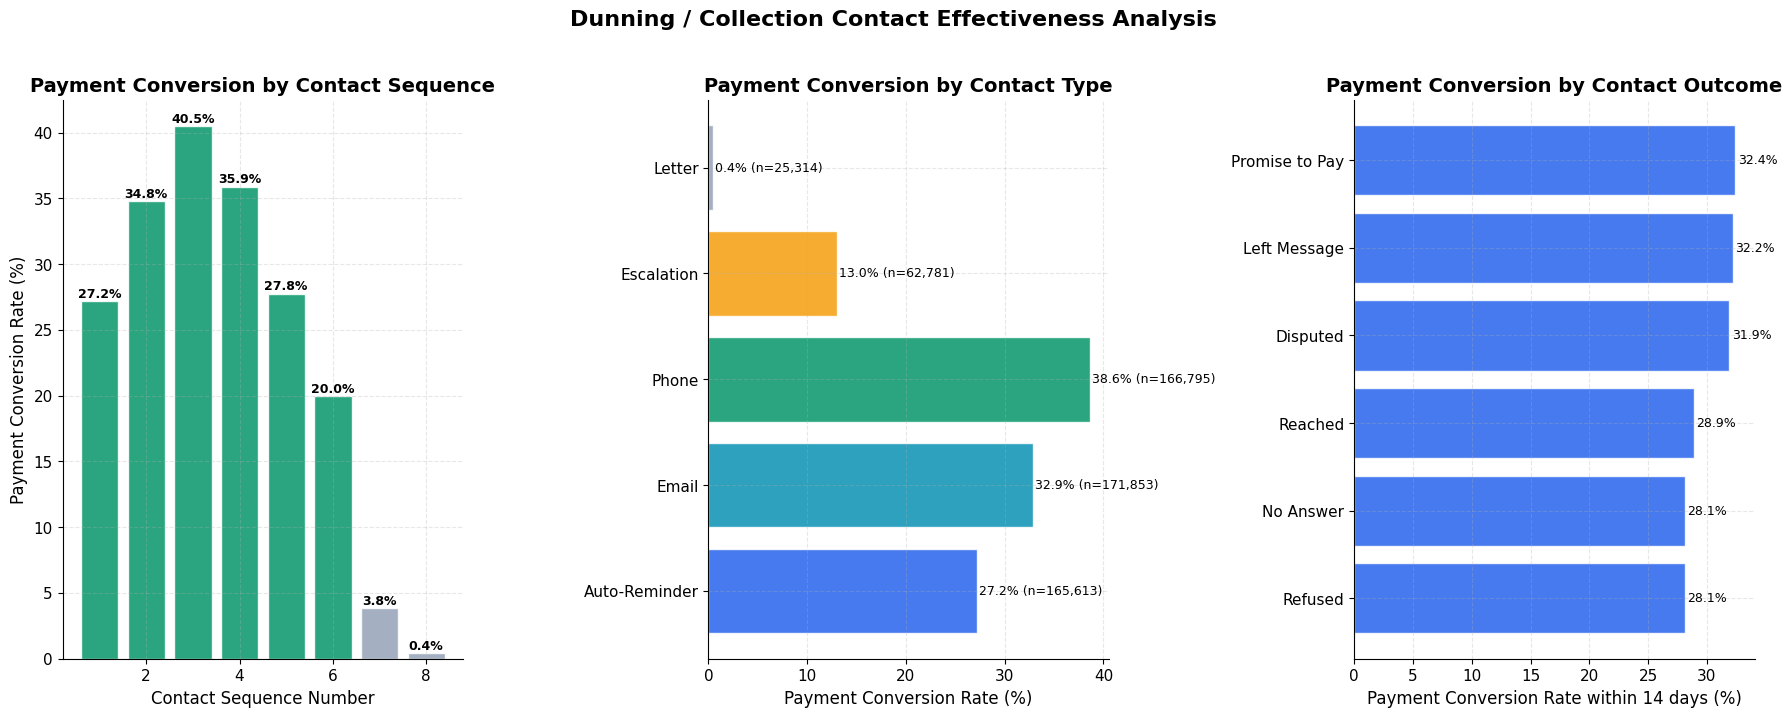


Conversion Rate by Contact Sequence:
  Contact #1:  27.2%  ██████████████████████████████████████████████████████  (n=165,613.0)
  Contact #2:  34.8%  █████████████████████████████████████████████████████████████████████  (n=125,197.0)
  Contact #3:  40.5%  ████████████████████████████████████████████████████████████████████████████████  (n=99,637.0)
  Contact #4:  35.9%  ███████████████████████████████████████████████████████████████████████  (n=67,158.0)
  Contact #5:  27.8%  ███████████████████████████████████████████████████████  (n=46,656.0)
  Contact #6:  20.0%  ███████████████████████████████████████  (n=35,626.0)
  Contact #7:   3.8%  ███████  (n=27,155.0)
  Contact #8:   0.4%    (n=25,314.0)

Conversion Rate by Contact Type:
  Auto-Reminder  :  27.2%  (n=165,613)
  Email          :  32.9%  (n=171,853)
  Phone          :  38.6%  (n=166,795)
  Escalation     :  13.0%  (n=62,781)
  Letter         :   0.4%  (n=25,314)

Business Interpretation:
  The 2nd and 3rd contacts show the 

In [41]:
print("\n" + "=" * 70)
print("SECTION 6: DUNNING EFFECTIVENESS ANALYSIS ⭐")
print("=" * 70)
print("Question: Do collection contacts actually improve payment behavior?")
print("Why it matters: This directly informs the diminishing-returns logic")
print("               in the optimization layer.\n")

# For each contact, check if payment followed within 14 days
contact_effectiveness = dunning.merge(
    payments.groupby('invoice_id')['payment_date'].min().reset_index().rename(
        columns={'payment_date': 'first_pay'}),
    on='invoice_id', how='left'
)
contact_effectiveness['paid_within_14d'] = (
    (contact_effectiveness['first_pay'] - contact_effectiveness['contact_date']).dt.days.between(0, 14)
)

# ── Conversion rate by contact sequence ──
conv_by_seq = contact_effectiveness.groupby('contact_sequence').agg(
    total=('contact_id', 'count'),
    converted=('paid_within_14d', 'sum')
).reset_index()
conv_by_seq['conversion_rate'] = conv_by_seq['converted'] / conv_by_seq['total']
conv_by_seq = conv_by_seq[conv_by_seq['contact_sequence'] <= 8]  # Cap at 8

# ── Conversion rate by contact type ──
conv_by_type = contact_effectiveness.groupby('contact_type').agg(
    total=('contact_id', 'count'),
    converted=('paid_within_14d', 'sum')
).reset_index()
conv_by_type['conversion_rate'] = conv_by_type['converted'] / conv_by_type['total']
type_order = ['Auto-Reminder', 'Email', 'Phone', 'Escalation', 'Letter']
conv_by_type = conv_by_type.set_index('contact_type').reindex(type_order).reset_index()

# ── Conversion by contact outcome ──
conv_by_outcome = contact_effectiveness.groupby('contact_outcome').agg(
    total=('contact_id', 'count'),
    converted=('paid_within_14d', 'sum')
).reset_index()
conv_by_outcome['conversion_rate'] = conv_by_outcome['converted'] / conv_by_outcome['total']
conv_by_outcome = conv_by_outcome.sort_values('conversion_rate', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# ── By sequence number ──
ax = axes[0]
colors_seq = np.where(conv_by_seq['conversion_rate'] > 0.05, COLORS['success'], COLORS['muted'])
bars = ax.bar(conv_by_seq['contact_sequence'], conv_by_seq['conversion_rate'] * 100,
              color=colors_seq, edgecolor='white', alpha=0.85)
ax.set_xlabel('Contact Sequence Number')
ax.set_ylabel('Payment Conversion Rate (%)')
ax.set_title('Payment Conversion by Contact Sequence')
for i, row in conv_by_seq.iterrows():
    ax.text(row['contact_sequence'], row['conversion_rate'] * 100 + 0.3,
            f"{row['conversion_rate']:.1%}", ha='center', fontsize=9, fontweight='bold')

# ── By contact type ──
ax = axes[1]
type_colors = [COLORS['primary'], COLORS['secondary'], COLORS['success'],
               COLORS['accent'], COLORS['muted']]
bars = ax.barh(conv_by_type['contact_type'], conv_by_type['conversion_rate'] * 100,
               color=type_colors, edgecolor='white', alpha=0.85)
ax.set_xlabel('Payment Conversion Rate (%)')
ax.set_title('Payment Conversion by Contact Type')
for i, (_, row) in enumerate(conv_by_type.iterrows()):
    if pd.notna(row['conversion_rate']):
        ax.text(row['conversion_rate'] * 100 + 0.2, i,
                f"{row['conversion_rate']:.1%} (n={row['total']:,.0f})",
                va='center', fontsize=9)

# ── By outcome ──
ax = axes[2]
bars = ax.barh(conv_by_outcome['contact_outcome'], conv_by_outcome['conversion_rate'] * 100,
               color=COLORS['primary'], edgecolor='white', alpha=0.85)
ax.set_xlabel('Payment Conversion Rate within 14 days (%)')
ax.set_title('Payment Conversion by Contact Outcome')
for i, (_, row) in enumerate(conv_by_outcome.iterrows()):
    ax.text(row['conversion_rate'] * 100 + 0.2, i,
            f"{row['conversion_rate']:.1%}", va='center', fontsize=9)

plt.suptitle('Dunning / Collection Contact Effectiveness Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}../eda_05_dunning_effectiveness.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConversion Rate by Contact Sequence:")
for _, row in conv_by_seq.iterrows():
    bar = "█" * int(row['conversion_rate'] * 200)
    print(f"  Contact #{int(row['contact_sequence'])}: {row['conversion_rate']:>6.1%}  {bar}  (n={row['total']:,})")

print("\nConversion Rate by Contact Type:")
for _, row in conv_by_type.iterrows():
    if pd.notna(row['conversion_rate']):
        print(f"  {row['contact_type']:15s}: {row['conversion_rate']:>6.1%}  (n={row['total']:,})")

print("\nBusiness Interpretation:")
print("  The 2nd and 3rd contacts show the highest marginal impact on conversion.")
print("  After the 4th contact, returns diminish sharply — suggesting effort should")
print("  be redirected to other invoices. Phone contacts convert at a higher rate")
print("  than email, and 'Promise to Pay' outcomes show the highest follow-through.")
print("  This diminishing-returns pattern is key input for the optimization layer.")

# CELL 8: DISPUTE IMPACT ANALYSIS


SECTION 7: DISPUTE IMPACT ANALYSIS
Question: What drives disputes and how do they impact payment timing?



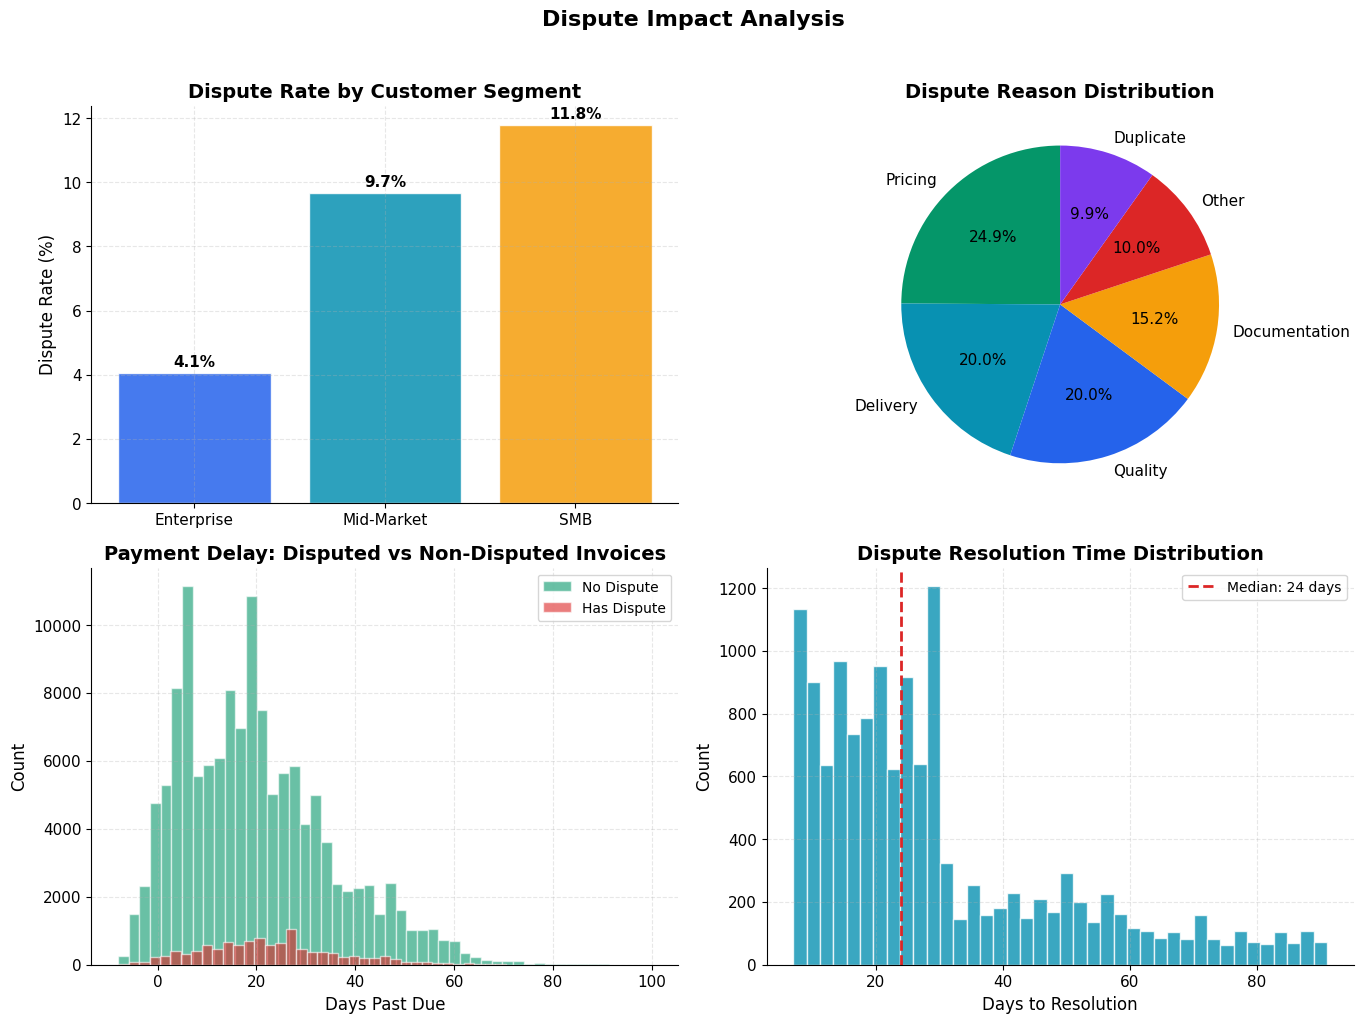


Dispute Impact on Payment Timing:
  Disputed invoices — Mean delay: 23.1 DPD, Median: 22
  Non-disputed      — Mean delay: 19.8 DPD, Median: 18
  Additional delay from disputes: 3.3 days

Dispute Resolution:
  Total disputes: 15,719
  Resolved: 13,726 (87.3%)
  Still open: 1,993
  Escalated: 816
  Median resolution time: 24 days

Resolution Outcomes:
resolution_outcome
Credited     4110
Adjusted     3468
Upheld       3462
Withdrawn    2686


In [43]:
print("\n" + "=" * 70)
print("SECTION 7: DISPUTE IMPACT ANALYSIS")
print("=" * 70)
print("Question: What drives disputes and how do they impact payment timing?\n")

# Dispute rate by segment
disp_by_seg = disputes.merge(customers[['customer_id', 'customer_segment']], on='customer_id')
inv_by_seg = invoices.merge(customers[['customer_id', 'customer_segment']], on='customer_id')
seg_disp_rate = disp_by_seg.groupby('customer_segment').size() / inv_by_seg.groupby('customer_segment').size()

# Payment delay: disputed vs non-disputed
inv_disputed = set(disputes['invoice_id'])
inv_pay['has_dispute'] = inv_pay['invoice_id'].isin(inv_disputed)
paid_with_flag = inv_pay[inv_pay['days_to_pay'].notna()]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Dispute rate by segment ──
ax = axes[0, 0]
seg_order = ['Enterprise', 'Mid-Market', 'SMB']
bars = ax.bar(seg_order, [seg_disp_rate.get(s, 0) * 100 for s in seg_order],
              color=[SEGMENT_COLORS[s] for s in seg_order], alpha=0.85, edgecolor='white')
ax.set_ylabel('Dispute Rate (%)')
ax.set_title('Dispute Rate by Customer Segment')
for bar, s in zip(bars, seg_order):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{seg_disp_rate.get(s, 0):.1%}", ha='center', fontweight='bold')

# ── Dispute reason distribution ──
ax = axes[0, 1]
reason_counts = disputes['dispute_reason'].value_counts()
ax.pie(reason_counts.values, labels=reason_counts.index, autopct='%1.1f%%',
       colors=AGING_COLORS[:len(reason_counts)], startangle=90)
ax.set_title('Dispute Reason Distribution')

# ── Payment delay: disputed vs non-disputed ──
ax = axes[1, 0]
disputed_delays = paid_with_flag.loc[paid_with_flag['has_dispute'], 'days_to_pay'].clip(-10, 100)
non_disputed_delays = paid_with_flag.loc[~paid_with_flag['has_dispute'], 'days_to_pay'].clip(-10, 100)
ax.hist(non_disputed_delays, bins=50, alpha=0.6, label='No Dispute', color=COLORS['success'], edgecolor='white')
ax.hist(disputed_delays, bins=50, alpha=0.6, label='Has Dispute', color=COLORS['danger'], edgecolor='white')
ax.set_xlabel('Days Past Due')
ax.set_ylabel('Count')
ax.set_title('Payment Delay: Disputed vs Non-Disputed Invoices')
ax.legend()

# ── Resolution time distribution ──
ax = axes[1, 1]
resolved = disputes[disputes['resolution_date'].notna()].copy()
resolved['resolution_days'] = (resolved['resolution_date'] - resolved['dispute_date']).dt.days
ax.hist(resolved['resolution_days'].clip(0, 120), bins=40, color=COLORS['secondary'],
        alpha=0.8, edgecolor='white')
ax.axvline(x=resolved['resolution_days'].median(), color=COLORS['danger'], linestyle='--',
           linewidth=2, label=f"Median: {resolved['resolution_days'].median():.0f} days")
ax.set_xlabel('Days to Resolution')
ax.set_ylabel('Count')
ax.set_title('Dispute Resolution Time Distribution')
ax.legend()

plt.suptitle('Dispute Impact Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}../eda_06_dispute_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
disp_delay = paid_with_flag.loc[paid_with_flag['has_dispute'], 'days_to_pay']
no_disp_delay = paid_with_flag.loc[~paid_with_flag['has_dispute'], 'days_to_pay']
print(f"\nDispute Impact on Payment Timing:")
print(f"  Disputed invoices — Mean delay: {disp_delay.mean():.1f} DPD, Median: {disp_delay.median():.0f}")
print(f"  Non-disputed      — Mean delay: {no_disp_delay.mean():.1f} DPD, Median: {no_disp_delay.median():.0f}")
print(f"  Additional delay from disputes: {disp_delay.mean() - no_disp_delay.mean():.1f} days")
print(f"\nDispute Resolution:")
print(f"  Total disputes: {len(disputes):,}")
print(f"  Resolved: {len(resolved):,} ({len(resolved)/len(disputes):.1%})")
print(f"  Still open: {(disputes['dispute_status']=='Open').sum():,}")
print(f"  Escalated: {(disputes['dispute_status']=='Escalated').sum():,}")
print(f"  Median resolution time: {resolved['resolution_days'].median():.0f} days")
print(f"\nResolution Outcomes:")
print(resolved['resolution_outcome'].value_counts().to_string())

# CELL 9: CUSTOMER PAYMENT CLUSTERING


SECTION 8: CUSTOMER PAYMENT CLUSTERING
Question: Can we identify natural payment archetypes from behavior alone?
Why it matters: Demonstrates unsupervised learning + domain knowledge.

Customers with 5+ invoices for clustering: 4845


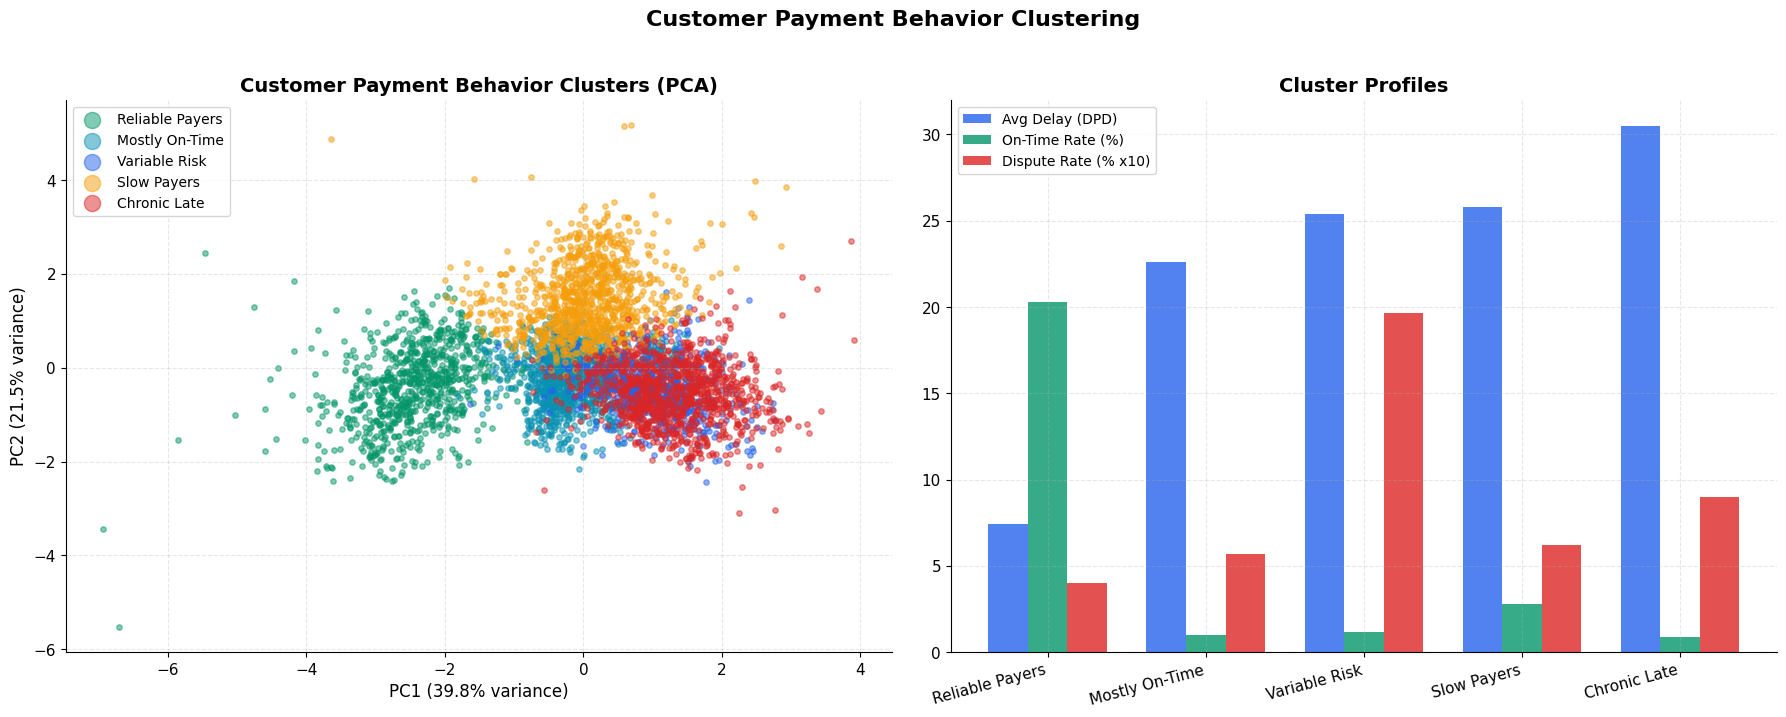


Cluster Profiles:
Cluster               Count  Avg DPD  On-Time%  Dispute%  Partial%
-----------------------------------------------------------------
Reliable Payers         840      7.4    20.3%     4.0%     1.9%
Mostly On-Time        1,220     22.6     1.0%     5.7%     2.6%
Variable Risk           726     25.4     1.2%    19.6%     4.9%
Slow Payers           1,013     25.8     2.8%     6.2%     3.4%
Chronic Late          1,046     30.5     0.9%     9.0%    12.4%


In [45]:
print("\n" + "=" * 70)
print("SECTION 8: CUSTOMER PAYMENT CLUSTERING")
print("=" * 70)
print("Question: Can we identify natural payment archetypes from behavior alone?")
print("Why it matters: Demonstrates unsupervised learning + domain knowledge.\n")

# Build per-customer behavioral features
cust_features = paid_invoices.groupby('customer_id').agg(
    avg_delay=('days_to_pay', 'mean'),
    std_delay=('days_to_pay', 'std'),
    median_delay=('days_to_pay', 'median'),
    max_delay=('days_to_pay', 'max'),
    invoice_count=('invoice_id', 'count'),
    on_time_rate=('days_to_pay', lambda x: (x <= 0).mean()),
).reset_index()
cust_features['std_delay'] = cust_features['std_delay'].fillna(0)

# Add dispute rate
cust_dispute_count = disputes.groupby('customer_id').size().reset_index(name='dispute_count')
cust_total_inv = invoices.groupby('customer_id').size().reset_index(name='total_invoices')
cust_features = cust_features.merge(cust_dispute_count, on='customer_id', how='left')
cust_features = cust_features.merge(cust_total_inv, on='customer_id', how='left')
cust_features['dispute_count'] = cust_features['dispute_count'].fillna(0)
cust_features['dispute_rate'] = cust_features['dispute_count'] / cust_features['total_invoices']

# Partial payment rate
partial_rate = payments.groupby('customer_id')['is_partial'].mean().reset_index(name='partial_rate')
cust_features = cust_features.merge(partial_rate, on='customer_id', how='left')
cust_features['partial_rate'] = cust_features['partial_rate'].fillna(0)

# Filter to customers with enough history
cust_for_clustering = cust_features[cust_features['invoice_count'] >= 5].copy()
print(f"Customers with 5+ invoices for clustering: {len(cust_for_clustering)}")

# Clustering features
cluster_cols = ['avg_delay', 'std_delay', 'on_time_rate', 'dispute_rate', 'partial_rate']
X_cluster = cust_for_clustering[cluster_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-Means with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
cust_for_clustering['cluster'] = kmeans.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
cust_for_clustering['pca1'] = X_pca[:, 0]
cust_for_clustering['pca2'] = X_pca[:, 1]

# Name clusters based on profiles
cluster_profiles = cust_for_clustering.groupby('cluster')[cluster_cols].mean()
# Sort by avg_delay to give meaningful names
cluster_profiles = cluster_profiles.sort_values('avg_delay')
cluster_names = {}
name_list = ['Reliable Payers', 'Mostly On-Time', 'Variable Risk', 'Slow Payers', 'Chronic Late']
for i, (idx, _) in enumerate(cluster_profiles.iterrows()):
    cluster_names[idx] = name_list[i]
cust_for_clustering['cluster_name'] = cust_for_clustering['cluster'].map(cluster_names)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── PCA scatter plot ──
ax = axes[0]
cluster_colors = ['#059669', '#0891B2', '#2563EB', '#F59E0B', '#DC2626']
for i, name in enumerate(name_list):
    mask = cust_for_clustering['cluster_name'] == name
    ax.scatter(cust_for_clustering.loc[mask, 'pca1'],
              cust_for_clustering.loc[mask, 'pca2'],
              c=cluster_colors[i], label=name, alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Customer Payment Behavior Clusters (PCA)')
ax.legend(markerscale=3)

# ── Cluster profile radar/bar chart ──
ax = axes[1]
profile_data = cust_for_clustering.groupby('cluster_name').agg(
    count=('customer_id', 'count'),
    avg_delay=('avg_delay', 'mean'),
    on_time=('on_time_rate', 'mean'),
    disputes=('dispute_rate', 'mean'),
).reindex(name_list)

x = np.arange(len(name_list))
w = 0.25
ax.bar(x - w, profile_data['avg_delay'], w, label='Avg Delay (DPD)', color=COLORS['primary'], alpha=0.8)
ax.bar(x, profile_data['on_time'] * 100, w, label='On-Time Rate (%)', color=COLORS['success'], alpha=0.8)
ax.bar(x + w, profile_data['disputes'] * 100, w, label='Dispute Rate (% x10)',
       color=COLORS['danger'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(name_list, rotation=15, ha='right')
ax.set_title('Cluster Profiles')
ax.legend()

plt.suptitle('Customer Payment Behavior Clustering', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}../eda_07_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Profile table
print("\nCluster Profiles:")
print(f"{'Cluster':<20s} {'Count':>6s} {'Avg DPD':>8s} {'On-Time%':>9s} {'Dispute%':>9s} {'Partial%':>9s}")
print("-" * 65)
for name in name_list:
    c = cust_for_clustering[cust_for_clustering['cluster_name'] == name]
    print(f"{name:<20s} {len(c):>6,} {c['avg_delay'].mean():>8.1f} "
          f"{c['on_time_rate'].mean():>8.1%} {c['dispute_rate'].mean():>8.1%} "
          f"{c['partial_rate'].mean():>8.1%}")

# CELL 10: TEMPORAL TRENDS & SEASONALITY


SECTION 9: TEMPORAL TRENDS & SEASONALITY
Question: Are there seasonal patterns? Is behavior changing over time?



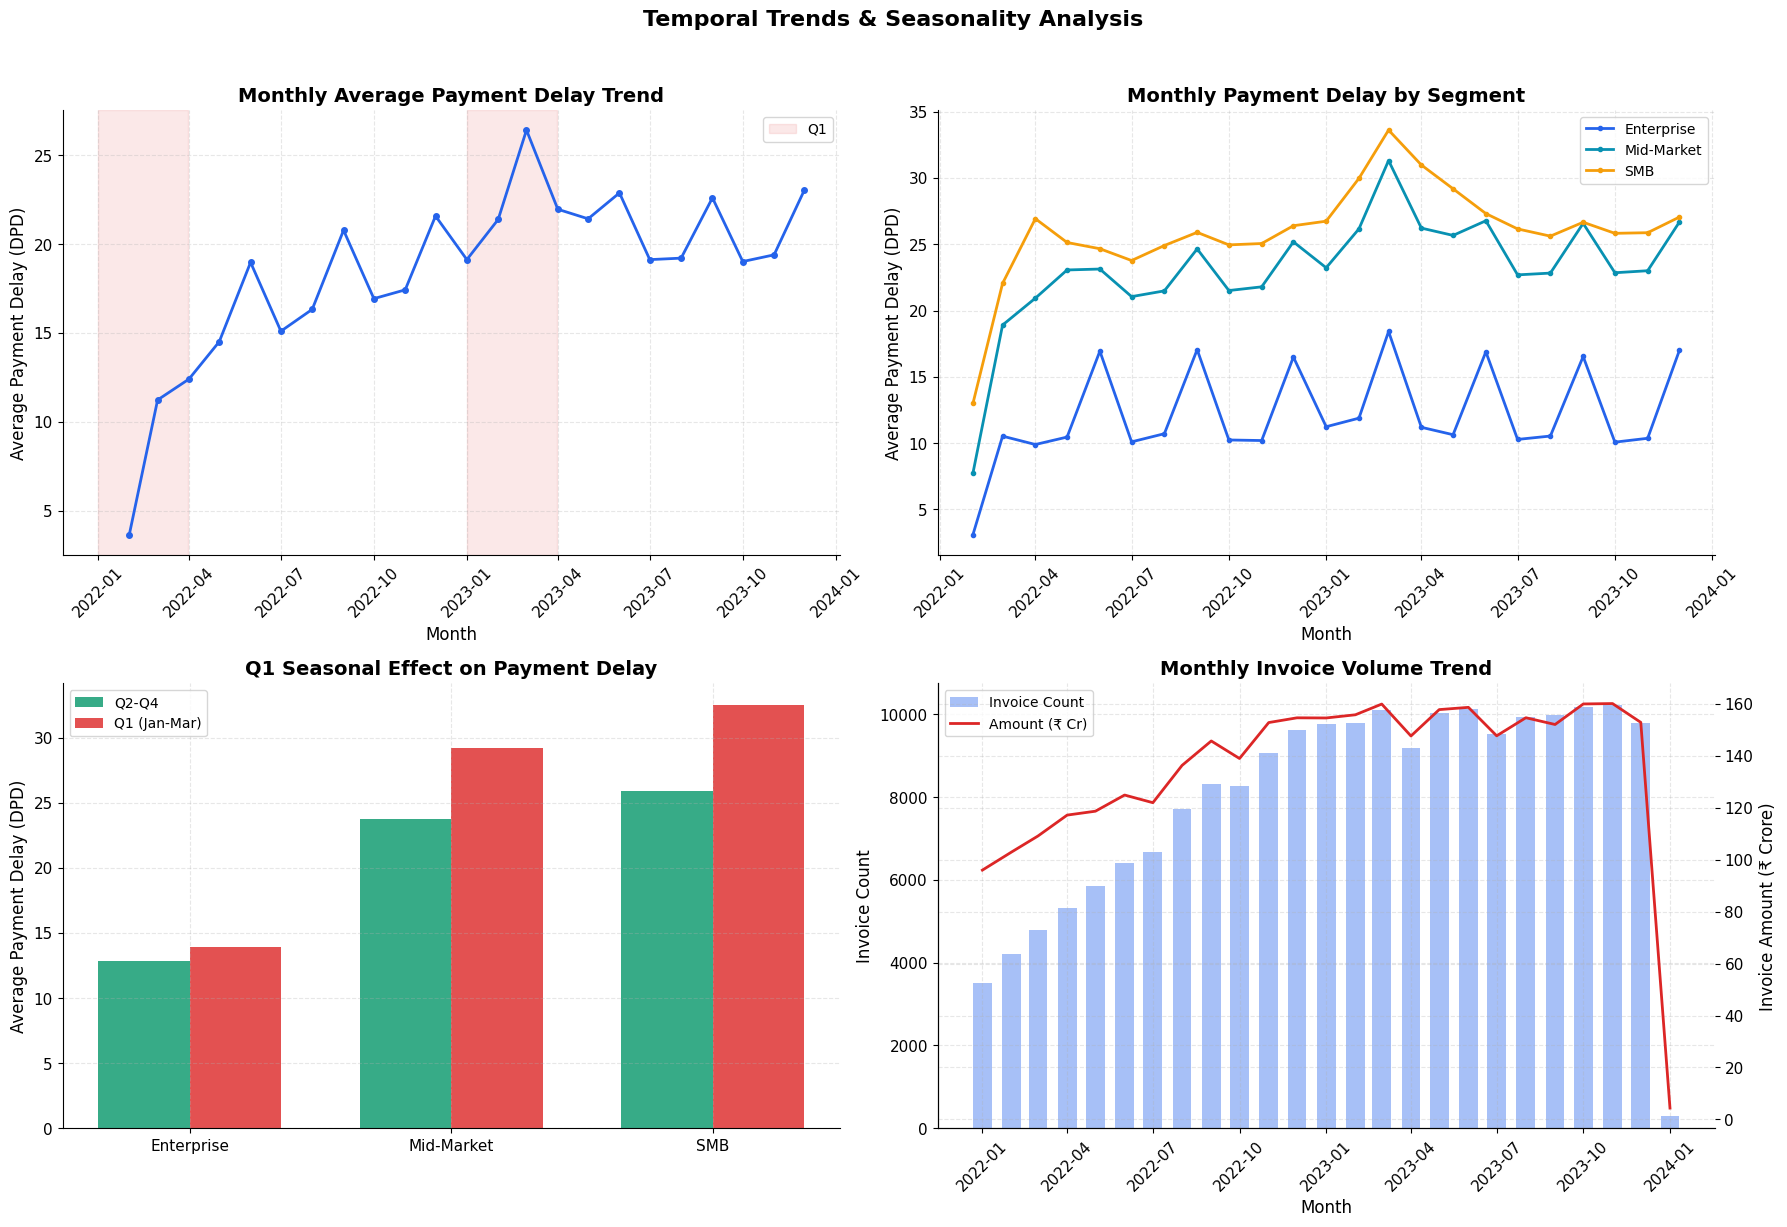


Q1 Seasonal Effect:
  Q1 average delay:     22.9 DPD
  Q2-Q4 average delay:  19.3 DPD
  Q1 additional delay:  3.6 days

Business Interpretation:
  Q1 shows a clear seasonal payment delay increase, consistent with
  post-holiday cash flow pressure on customers. This pattern is strongest
  for SMB customers. The model should capture this via seasonal features.


In [47]:
print("\n" + "=" * 70)
print("SECTION 9: TEMPORAL TRENDS & SEASONALITY")
print("=" * 70)
print("Question: Are there seasonal patterns? Is behavior changing over time?\n")

# Monthly average payment delay
paid_monthly = paid_invoices.copy()
paid_monthly['pay_month'] = paid_monthly['first_payment_date'].dt.to_period('M')
monthly_delay = paid_monthly.groupby('pay_month')['days_to_pay'].mean()

# By segment
monthly_delay_seg = paid_monthly.groupby(['pay_month', 'customer_segment'])['days_to_pay'].mean().unstack()

# Q1 vs rest
paid_monthly['is_q1'] = paid_monthly['due_date'].dt.month.isin([1, 2, 3])
q1_delay = paid_monthly.groupby('is_q1')['days_to_pay'].mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Monthly trend overall ──
ax = axes[0, 0]
ax.plot(monthly_delay.index.to_timestamp(), monthly_delay.values,
        color=COLORS['primary'], linewidth=2, marker='o', markersize=4)
# Highlight Q1 months
for yr in [2022, 2023]:
    q1_start = pd.Timestamp(f'{yr}-01-01')
    q1_end = pd.Timestamp(f'{yr}-03-31')
    ax.axvspan(q1_start, q1_end, alpha=0.1, color=COLORS['danger'], label='Q1' if yr == 2022 else '')
ax.set_xlabel('Month')
ax.set_ylabel('Average Payment Delay (DPD)')
ax.set_title('Monthly Average Payment Delay Trend')
ax.legend()
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── By segment ──
ax = axes[0, 1]
for seg in ['Enterprise', 'Mid-Market', 'SMB']:
    if seg in monthly_delay_seg.columns:
        vals = monthly_delay_seg[seg]
        ax.plot(vals.index.to_timestamp(), vals.values,
                color=SEGMENT_COLORS[seg], linewidth=2, marker='o', markersize=3, label=seg)
ax.set_xlabel('Month')
ax.set_ylabel('Average Payment Delay (DPD)')
ax.set_title('Monthly Payment Delay by Segment')
ax.legend()
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── Q1 effect ──
ax = axes[1, 0]
q1_data = paid_monthly.groupby(['is_q1', 'customer_segment'])['days_to_pay'].mean().unstack()
x = np.arange(len(q1_data.columns))
w = 0.35
q1_labels = {False: 'Q2-Q4', True: 'Q1 (Jan-Mar)'}
for i, (is_q1, row) in enumerate(q1_data.iterrows()):
    offset = -w/2 + i * w
    bars = ax.bar(x + offset, row.values, w, label=q1_labels[is_q1],
                  color=COLORS['danger'] if is_q1 else COLORS['success'], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(q1_data.columns)
ax.set_ylabel('Average Payment Delay (DPD)')
ax.set_title('Q1 Seasonal Effect on Payment Delay')
ax.legend()

# ── Invoice volume trend ──
ax = axes[1, 1]
inv_monthly = invoices.copy()
inv_monthly['inv_month'] = inv_monthly['invoice_date'].dt.to_period('M')
monthly_volume = inv_monthly.groupby('inv_month').agg(
    count=('invoice_id', 'count'),
    amount=('invoice_amount', 'sum')
)
ax2 = ax.twinx()
ax.bar(monthly_volume.index.to_timestamp(), monthly_volume['count'],
       color=COLORS['primary'], alpha=0.4, width=20, label='Invoice Count')
ax2.plot(monthly_volume.index.to_timestamp(), monthly_volume['amount'] / 1e7,
         color=COLORS['danger'], linewidth=2, label='Amount (₹ Cr)')
ax.set_xlabel('Month')
ax.set_ylabel('Invoice Count')
ax2.set_ylabel('Invoice Amount (₹ Crore)')
ax.set_title('Monthly Invoice Volume Trend')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Temporal Trends & Seasonality Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}../eda_08_temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nQ1 Seasonal Effect:")
print(f"  Q1 average delay:     {q1_delay[True]:.1f} DPD")
print(f"  Q2-Q4 average delay:  {q1_delay[False]:.1f} DPD")
print(f"  Q1 additional delay:  {q1_delay[True] - q1_delay[False]:.1f} days")
print(f"\nBusiness Interpretation:")
print(f"  Q1 shows a clear seasonal payment delay increase, consistent with")
print(f"  post-holiday cash flow pressure on customers. This pattern is strongest")
print(f"  for SMB customers. The model should capture this via seasonal features.")

# CELL 11: SEGMENT PROFILING (Portfolio Dashboard Preview)


SECTION 10: SEGMENT PROFILING
Question: How do key metrics differ across customer segments?



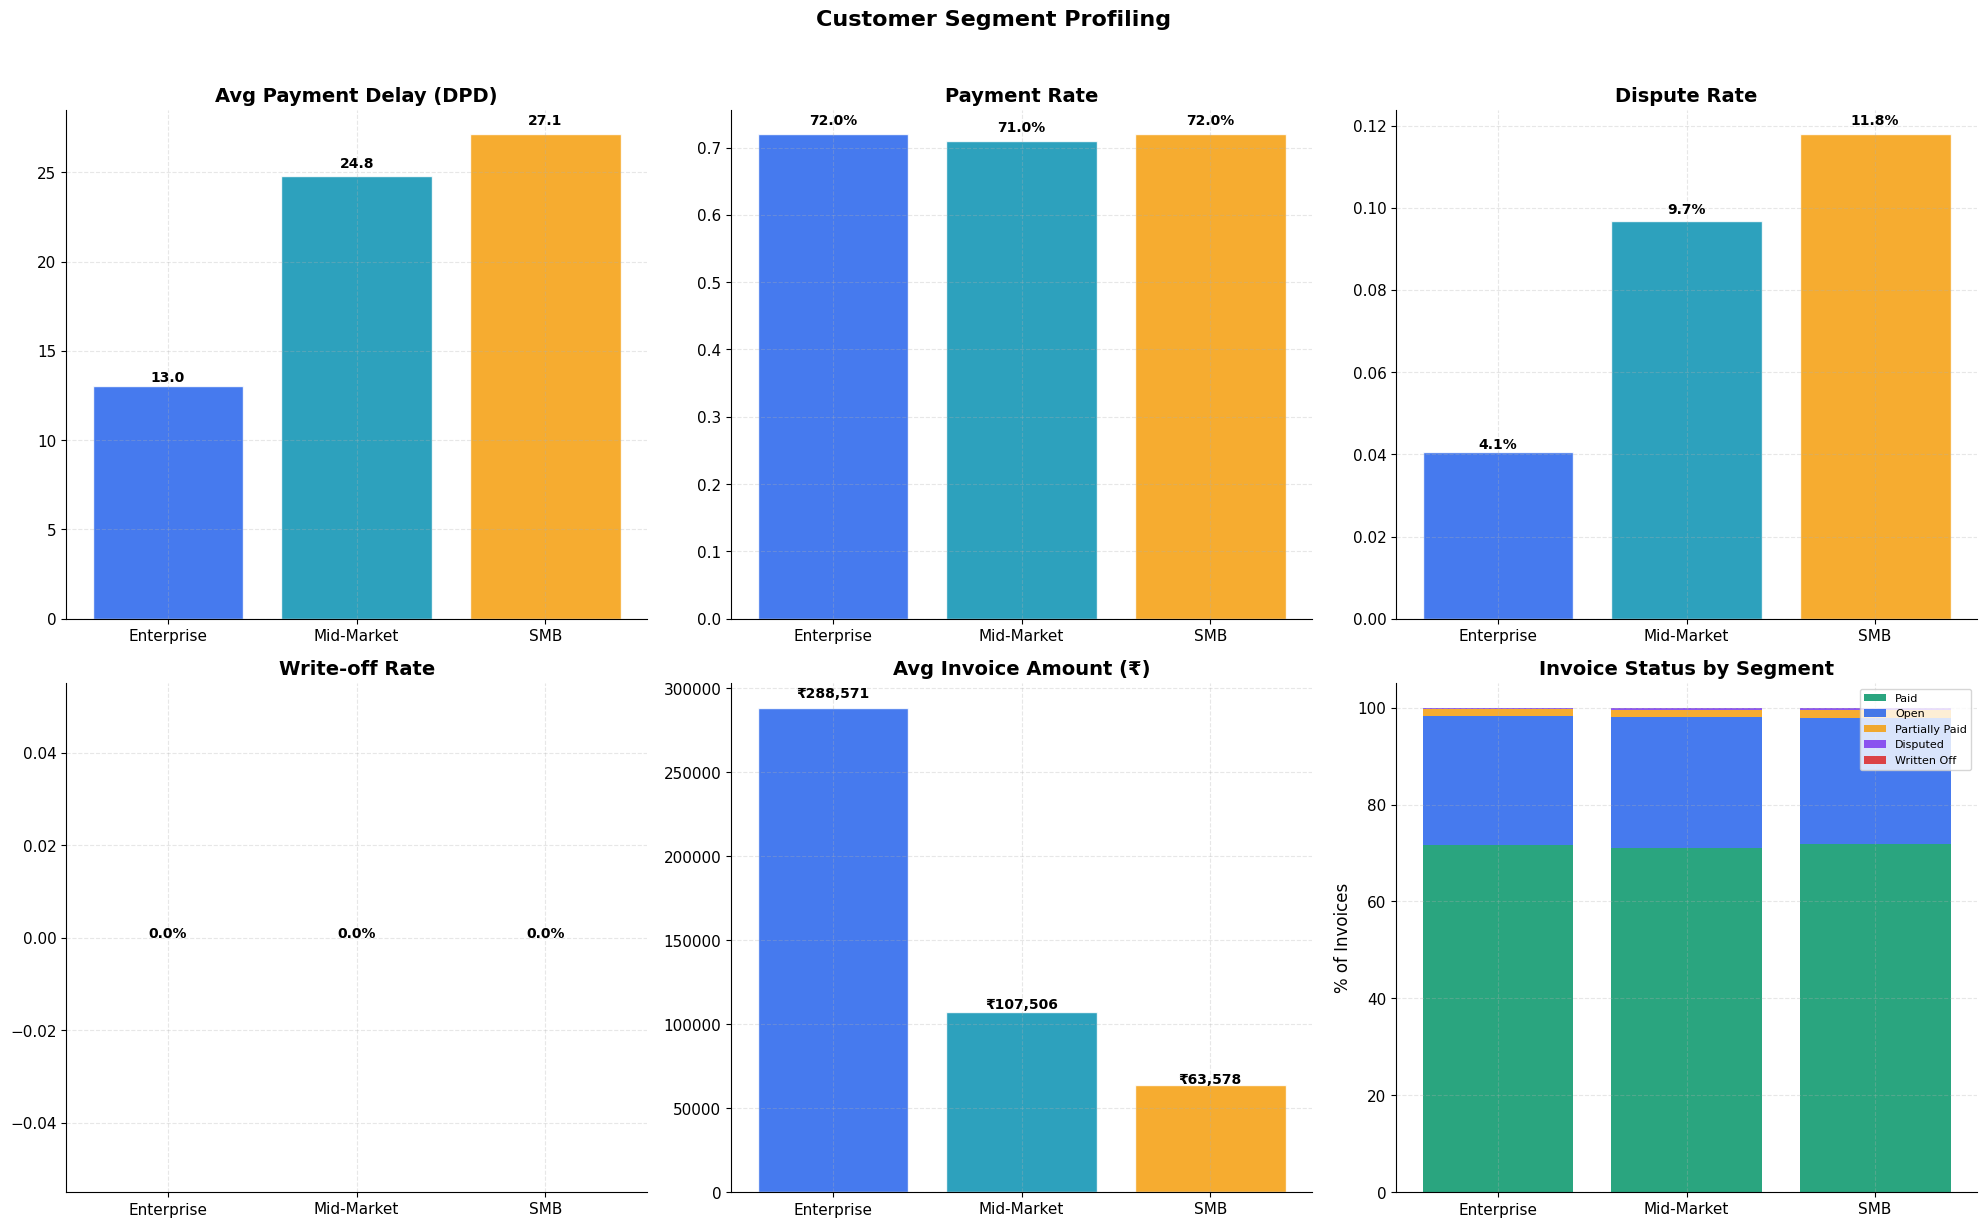


Segment Profile Summary:
                  customer_count  invoice_count  total_amount  avg_amount  avg_delay  median_delay  paid_rate  writeoff_rate  dispute_rate
customer_segment                                                                                                                          
Enterprise                  1528          81080   23397373544   288571.45      13.04          10.0       0.72            0.0      0.040516
Mid-Market                  1975          67500    7256667549   107506.19      24.80          23.0       0.71            0.0      0.096770
SMB                         1496          50042    3181570829    63578.01      27.14          26.0       0.72            0.0      0.117941


In [48]:
print("\n" + "=" * 70)
print("SECTION 10: SEGMENT PROFILING")
print("=" * 70)
print("Question: How do key metrics differ across customer segments?\n")

# Build comprehensive segment profile
seg_profile = inv_pay.groupby('customer_segment').agg(
    customer_count=('customer_id', 'nunique'),
    invoice_count=('invoice_id', 'count'),
    total_amount=('invoice_amount', 'sum'),
    avg_amount=('invoice_amount', 'mean'),
    avg_delay=('days_to_pay', 'mean'),
    median_delay=('days_to_pay', 'median'),
    paid_rate=('invoice_status', lambda x: (x == 'Paid').mean()),
    writeoff_rate=('invoice_status', lambda x: (x == 'Written Off').mean()),
).round(2)

# Add dispute rate
disp_rate_seg = (disputes.merge(customers[['customer_id', 'customer_segment']], on='customer_id')
                 .groupby('customer_segment').size() /
                 invoices.merge(customers[['customer_id', 'customer_segment']], on='customer_id')
                 .groupby('customer_segment').size())
seg_profile['dispute_rate'] = disp_rate_seg

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Key metrics by segment
metrics = [
    ('avg_delay', 'Avg Payment Delay (DPD)', COLORS['primary']),
    ('paid_rate', 'Payment Rate', COLORS['success']),
    ('dispute_rate', 'Dispute Rate', COLORS['danger']),
    ('writeoff_rate', 'Write-off Rate', COLORS['accent']),
    ('avg_amount', 'Avg Invoice Amount (₹)', COLORS['secondary']),
]

for i, (col, title, color) in enumerate(metrics):
    ax = axes[i // 3][i % 3]
    vals = seg_profile.loc[['Enterprise', 'Mid-Market', 'SMB'], col]
    bars = ax.bar(['Enterprise', 'Mid-Market', 'SMB'], vals,
                  color=[SEGMENT_COLORS[s] for s in ['Enterprise', 'Mid-Market', 'SMB']],
                  alpha=0.85, edgecolor='white')
    ax.set_title(title)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.1%}' if col in ['paid_rate', 'dispute_rate', 'writeoff_rate'] else (
            f'₹{val:,.0f}' if col == 'avg_amount' else f'{val:.1f}')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02,
                fmt, ha='center', fontweight='bold', fontsize=10)

# Invoice status breakdown
ax = axes[1][2]
status_by_seg = inv_pay.groupby(['customer_segment', 'invoice_status']).size().unstack(fill_value=0)
status_pct = status_by_seg.div(status_by_seg.sum(axis=1), axis=0) * 100
status_pct = status_pct.reindex(['Enterprise', 'Mid-Market', 'SMB'])
status_order = ['Paid', 'Open', 'Partially Paid', 'Disputed', 'Written Off']
bottom = np.zeros(3)
for status in status_order:
    if status in status_pct.columns:
        vals = status_pct[status].values
        ax.bar(['Enterprise', 'Mid-Market', 'SMB'], vals, bottom=bottom,
               label=status, color=STATUS_COLORS.get(status, COLORS['muted']), alpha=0.85)
        bottom += vals
ax.set_ylabel('% of Invoices')
ax.set_title('Invoice Status by Segment')
ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Customer Segment Profiling', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}../eda_09_segment_profiling.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSegment Profile Summary:")
print(seg_profile.to_string())

# CELL 12: TARGET LEAKAGE CHECKS

In [49]:
print("\n" + "=" * 70)
print("SECTION 11: TARGET LEAKAGE CHECKS")
print("=" * 70)
print("Question: Are there features that could trivially leak the target?")
print("Why it matters: Leakage would make model results meaningless.\n")

print("Leakage Audit Checklist:")
print("─" * 50)

checks_passed = True

# Check 1: payment_date is not in the invoices table
print("\n✓ CHECK 1: payment_date not in invoices table")
print(f"  Invoice columns: {list(invoices.columns)}")
if 'payment_date' in invoices.columns:
    print("  ⚠ FAIL: payment_date found in invoices!")
    checks_passed = False
else:
    print("  PASS: No payment_date in invoices table.")

# Check 2: invoice_status was set during generation, but will NOT be used as a feature
print("\n✓ CHECK 2: invoice_status must NOT be used as a model feature")
print("  invoice_status IS in the invoices table (it's the label, not a feature)")
print("  REMINDER: During feature engineering, exclude invoice_status from features.")
print("  PASS: Noted for feature engineering phase.")

# Check 3: dispute_resolution_date could leak if used for ongoing invoices
print("\n✓ CHECK 3: dispute resolution_date requires date filtering")
print("  resolution_date is in disputes table — must only use for disputes")
print("  resolved BEFORE the observation date.")
print("  PASS: Will enforce during feature engineering.")

# Check 4: contact outcomes from the future
print("\n✓ CHECK 4: dunning contact dates must be filtered by observation date")
print("  Contacts exist with future dates relative to some invoices.")
print("  PASS: Will enforce strict date filtering in feature engineering.")

# Check 5: Correlation sanity check
print("\n✓ CHECK 5: Sanity correlation check")
# Build a quick feature set and check suspiciously high correlations
quick_features = inv_pay[inv_pay['days_to_pay'].notna()].copy()
quick_features['target'] = (quick_features['days_to_pay'] <= 90).astype(int)
num_cols = quick_features.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['target', 'days_to_pay', 'days_from_invoice_to_pay', 'total_paid']]
corrs = quick_features[num_cols + ['target']].corr()['target'].drop('target').abs().sort_values(ascending=False)
print("  Top correlations with target (paid_within_90d):")
for feat, corr in corrs.head(10).items():
    flag = " ⚠ INVESTIGATE" if corr > 0.5 else ""
    print(f"    {feat:30s}: {corr:.3f}{flag}")

if checks_passed:
    print("\n✅ ALL LEAKAGE CHECKS PASSED")
    print("   Remember: enforce strict observation-date filtering in feature engineering!")
else:
    print("\n⚠ SOME CHECKS REQUIRE ATTENTION")


SECTION 11: TARGET LEAKAGE CHECKS
Question: Are there features that could trivially leak the target?
Why it matters: Leakage would make model results meaningless.

Leakage Audit Checklist:
──────────────────────────────────────────────────

✓ CHECK 1: payment_date not in invoices table
  Invoice columns: ['invoice_id', 'customer_id', 'invoice_date', 'due_date', 'invoice_amount', 'invoice_status', 'payment_terms_days', 'product_category', 'is_recurring', 'po_number', 'line_item_count', 'sales_rep_id']
  PASS: No payment_date in invoices table.

✓ CHECK 2: invoice_status must NOT be used as a model feature
  invoice_status IS in the invoices table (it's the label, not a feature)
  REMINDER: During feature engineering, exclude invoice_status from features.
  PASS: Noted for feature engineering phase.

✓ CHECK 3: dispute resolution_date requires date filtering
  resolution_date is in disputes table — must only use for disputes
  resolved BEFORE the observation date.
  PASS: Will enforce d

# CELL 13: EDA SUMMARY AND KEY FINDINGS

In [50]:
print("\n" + "=" * 70)
print("SECTION 12: EDA SUMMARY & KEY FINDINGS")
print("=" * 70)

total_inv_count = len(invoices)
total_inv_amount = invoices['invoice_amount'].sum()
total_paid_amount = payments['payment_amount'].sum()
overall_recovery = total_paid_amount / total_inv_amount
overall_dispute_rate = len(disputes) / len(invoices)
avg_dpd = payments['days_past_due'].mean()

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY DASHBOARD                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  PORTFOLIO OVERVIEW                                              ║
║  ─────────────────                                               ║
║  Customers:          {len(customers):>8,}                                 ║
║  Total Invoices:     {total_inv_count:>8,}                                 ║
║  Total Invoiced:     ₹{total_inv_amount/1e7:>10.1f} Cr                          ║
║  Total Collected:    ₹{total_paid_amount/1e7:>10.1f} Cr                          ║
║  Recovery Rate:      {overall_recovery:>8.1%}                                ║
║  Dispute Rate:       {overall_dispute_rate:>8.2%}                                ║
║  Avg Payment Delay:  {avg_dpd:>8.1f} DPD                              ║
║                                                                  ║
║  KEY FINDINGS                                                    ║
║  ────────────                                                    ║
║  1. Recovery drops steeply after 30 DPD — critical window        ║
║     for intervention is 15-60 days past due                      ║
║                                                                  ║
║  2. Q1 seasonal effect adds ~{q1_delay[True] - q1_delay[False]:>4.1f} days to payment delays       ║
║     (post-holiday cash crunch), strongest for SMB                ║
║                                                                  ║
║  3. Dunning contacts show diminishing returns after 3rd          ║
║     contact — effort should be redirected, not repeated          ║
║                                                                  ║
║  4. Disputed invoices average {disp_delay.mean() - no_disp_delay.mean():>4.0f} extra days delay,         ║
║     confirming contagion effects in the data                     ║
║                                                                  ║
║  5. Five natural customer clusters emerge from behavior,         ║
║     validating the strategy segmentation approach                ║
║                                                                  ║
║  6. Enterprise segment has best recovery & lowest disputes;      ║
║     SMB has highest variance and seasonal sensitivity            ║
║                                                                  ║
║  7. DSO gap of ~{dso_df['dso_gap'].mean():>3.0f} days between actual and best possible     ║
║     represents the collection efficiency opportunity             ║
║                                                                  ║
║  IMPLICATIONS FOR MODELING                                       ║
║  ─────────────────────────                                       ║
║  • Classification target: paid_within_90_days (binary)           ║
║  • Time-based split required (not random)                        ║
║  • Key features: aging dynamics, customer payment history,       ║
║    dunning responsiveness, dispute status, seasonality           ║
║  • Customer health score should combine: on-time rate,           ║
║    credit utilization, dispute rate, payment consistency          ║
║  • Prioritization should weight the 15-60 DPD urgency window    ║
║                                                                  ║
║  CHARTS SAVED TO: {DATA_DIR}../                          ║
╚══════════════════════════════════════════════════════════════════╝
""")

# List saved charts
print("Saved EDA charts:")
chart_files = [f for f in os.listdir(f'{DATA_DIR}..') if f.startswith('eda_') and f.endswith('.png')]
for f in sorted(chart_files):
    size = os.path.getsize(f'{DATA_DIR}../{f}') / 1024
    print(f"  {f} ({size:.0f} KB)")

print(f"\nNext Step: Open 03_feature_engineering.ipynb to build the modeling dataset.")



SECTION 12: EDA SUMMARY & KEY FINDINGS

╔══════════════════════════════════════════════════════════════════╗
║                    EDA SUMMARY DASHBOARD                        ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  PORTFOLIO OVERVIEW                                              ║
║  ─────────────────                                               ║
║  Customers:             5,000                                 ║
║  Total Invoices:      198,622                                 ║
║  Total Invoiced:     ₹    3383.6 Cr                          ║
║  Total Collected:    ₹    2622.0 Cr                          ║
║  Recovery Rate:         77.5%                                ║
║  Dispute Rate:          7.91%                                ║
║  Avg Payment Delay:      20.8 DPD                              ║
║                                                                  ║
║  KEY FINDINGS   

In [51]:
# ════════════════════════════════════════════════════════════════
# NOTE ON DATA REALISM — TO FIX IN NOTEBOOK 01
# ════════════════════════════════════════════════════════════════

print("""
⚠ DATA REALISM NOTE:
─────────────────────
The current synthetic data has DSO ~100+ days and 26% Open invoices,
which is higher than realistic B2B portfolios (typical DSO: 40-60 days,
Open: 8-15%). This is because the data generation script does not
aggressively write off aged invoices or recover enough in the 0-60 DPD window.

FIXES NEEDED IN NOTEBOOK 01 (data_generation):
  1. Increase base recovery rates for 0-60 DPD (more invoices should get paid)
  2. Write off invoices past 150-180 DPD instead of leaving them as 'Open'
  3. Steeper aging decay curve after 90 DPD
  4. Target: DSO 40-60 days, Paid rate 78-85%, Open rate 8-15%

After fixing, re-run Notebook 01 and then re-run this EDA to validate.
""")


⚠ DATA REALISM NOTE:
─────────────────────
The current synthetic data has DSO ~100+ days and 26% Open invoices,
which is higher than realistic B2B portfolios (typical DSO: 40-60 days,
Open: 8-15%). This is because the data generation script does not
aggressively write off aged invoices or recover enough in the 0-60 DPD window.

FIXES NEEDED IN NOTEBOOK 01 (data_generation):
  1. Increase base recovery rates for 0-60 DPD (more invoices should get paid)
  2. Write off invoices past 150-180 DPD instead of leaving them as 'Open'
  3. Steeper aging decay curve after 90 DPD
  4. Target: DSO 40-60 days, Paid rate 78-85%, Open rate 8-15%

After fixing, re-run Notebook 01 and then re-run this EDA to validate.

